# MKM Parameter Sweep – Suzuki-Miyaura Cross-Coupling — **scipy version**

## 1 · Imports

In [1]:
import itertools
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.integrate import solve_ivp

warnings.filterwarnings("ignore")
%matplotlib inline

## 2 · Load kinetics data
The data is loaded in different DataFrame files. Also a function is defined that takes the Gibbs free energy of a specific species contained in that file.

In [ ]:
# *** Update this path to match your file location ***
DATA_PATH = r"NEW-Reizmann_AIMNet_Gtotal_msrrho_20C_120C_all_species_new_reduced_all_methods.csv"
df = pd.read_csv(DATA_PATH)

full_path_old = r"Reizmann_AIMNet_Gtotal_msrrho_20C_120C_all_species_new.csv"
df_old = pd.read_csv(full_path_old)

def get_G(df, species_name, temperature_C):
    row = df[(df["species_name"] == species_name) & (df["temperature_C"] == temperature_C)]
    if row.empty:
        raise ValueError(f"Species {species_name!r} not found at {temperature_C} C")
    return row["G_total_wb97mv_plus_Gcorr_plus_SMDTHF_kcal_mol"].values[0]

def get_G_old(df_old, species_name, temperature_C):
    row = df_old[(df_old["species_name"] == species_name) & (df_old["temperature_C"] == temperature_C)]
    if row.empty:
        raise ValueError(f"Species {species_name!r} not found at {temperature_C} C")
    return row["G_total_AIMNet_msrrho_kcal_mol"].values[0]

print(f"Loaded {len(df)} rows")
print(f"Columns: {list(df.columns)}")
df.head()

Loaded 44844 rows
Columns: ['species_name', 'species_class', 'temperature_C', 'Gcorr_msrrho_kcal_mol', 'G_total_AIMNet_msrrho_kcal_mol', 'G_total_wb97mv_plus_Gcorr_plus_SMDTHF_kcal_mol', 'G_total_wb97mv_plus_Gcorr_plus_SMDwater_kcal_mol', 'G_total_wb97mv_plus_Gcorr_plus_CPCMX_THF_kcal_mol', 'G_total_wb97mv_plus_Gcorr_plus_CPCMX_water_kcal_mol', 'G_total_uma_plus_Gcorr_plus_SMDTHF_kcal_mol', 'G_total_uma_plus_Gcorr_plus_SMDwater_kcal_mol', 'G_total_uma_plus_Gcorr_plus_CPCMX_THF_kcal_mol', 'G_total_uma_plus_Gcorr_plus_CPCMX_water_kcal_mol', 'G_total_r2scan3c_gas_plus_Gcorr_plus_SMDTHF_kcal_mol', 'G_total_r2scan3c_gas_plus_Gcorr_plus_SMDwater_kcal_mol', 'G_total_r2scan3c_gas_plus_Gcorr_plus_CPCMX_THF_kcal_mol', 'G_total_r2scan3c_gas_plus_Gcorr_plus_CPCMX_water_kcal_mol', 'xtbSPH_species_name', 'xtbSPH_species_class', 'xtbSPH_temperature_C', 'Gcorr_xtbSPH_kcal_mol', 'G_total_AIMNet_xtbSPH_kcal_mol', 'G_total_wb97mv_plus_xtbSPH_Gcorr_plus_SMDTHF_kcal_mol', 'G_total_wb97mv_plus_xtbSPH_Gcorr_

,species_name,species_class,temperature_C,Gcorr_msrrho_kcal_mol,G_total_AIMNet_msrrho_kcal_mol,G_total_wb97mv_plus_Gcorr_plus_SMDTHF_kcal_mol,G_total_wb97mv_plus_Gcorr_plus_SMDwater_kcal_mol,G_total_wb97mv_plus_Gcorr_plus_CPCMX_THF_kcal_mol,G_total_wb97mv_plus_Gcorr_plus_CPCMX_water_kcal_mol,G_total_uma_plus_Gcorr_plus_SMDTHF_kcal_mol,...,G_total_wb97mv_plus_xtbSPH_Gcorr_plus_CPCMX_THF_kcal_mol,G_total_wb97mv_plus_xtbSPH_Gcorr_plus_CPCMX_water_kcal_mol,G_total_uma_plus_xtbSPH_Gcorr_plus_SMDTHF_kcal_mol,G_total_uma_plus_xtbSPH_Gcorr_plus_SMDwater_kcal_mol,G_total_uma_plus_xtbSPH_Gcorr_plus_CPCMX_THF_kcal_mol,G_total_uma_plus_xtbSPH_Gcorr_plus_CPCMX_water_kcal_mol,G_total_r2scan3c_gas_plus_xtbSPH_Gcorr_plus_SMDTHF_kcal_mol,G_total_r2scan3c_gas_plus_xtbSPH_Gcorr_plus_SMDwater_kcal_mol,G_total_r2scan3c_gas_plus_xtbSPH_Gcorr_plus_CPCMX_THF_kcal_mol,G_total_r2scan3c_gas_plus_xtbSPH_Gcorr_plus_CPCMX_water_kcal_mol
0,BOH2Ar_compound_2_as_BOH2_35-dimethylisoxazole...,BOH2Ar,20.0,61.348672,-314005.456320,-314172.263788,-314175.604891,-314173.275246,-314174.448386,-314168.655097,...,-314172.620774,-314173.793914,-314168.000625,-314171.341727,-314169.012082,-314170.185222,-314092.039873,-314095.380975,-314093.051330,-314094.224470
1,BOH2Ar_compound_2_as_BOH2_35-dimethylisoxazole...,BOH2Ar,21.0,61.245402,-314005.559589,-314172.367058,-314175.708161,-314173.378516,-314174.551656,-314168.758367,...,-314172.717096,-314173.890236,-314168.096947,-314171.438050,-314169.108405,-314170.281545,-314092.136195,-314095.477298,-314093.147653,-314094.320793
2,BOH2Ar_compound_2_as_BOH2_35-dimethylisoxazole...,BOH2Ar,22.0,61.141999,-314005.662992,-314172.470461,-314175.811564,-314173.481919,-314174.655059,-314168.861770,...,-314172.813545,-314173.986685,-314168.193396,-314171.534498,-314169.204853,-314170.377993,-314092.232644,-314095.573746,-314093.244101,-314094.417241
3,BOH2Ar_compound_2_as_BOH2_35-dimethylisoxazole...,BOH2Ar,23.0,61.038463,-314005.766528,-314172.573997,-314175.915100,-314173.585455,-314174.758595,-314168.965306,...,-314172.910181,-314174.083321,-314168.290032,-314171.631135,-314169.301490,-314170.474630,-314092.329280,-314095.670383,-314093.340738,-314094.513878
4,BOH2Ar_compound_2_as_BOH2_35-dimethylisoxazole...,BOH2Ar,24.0,60.934794,-314005.870197,-314172.677666,-314176.018769,-314173.689124,-314174.862264,-314169.068975,...,-314173.006880,-314174.180020,-314168.386731,-314171.727834,-314169.398189,-314170.571329,-314092.425979,-314095.767082,-314093.437437,-314094.610577


## 3. Experimental conditions + Sweep settings
The sweep over the different conditions is taken for a specific case (aryl halide, and boron species). It could however, easily be changed to include in the parameters to sweep. The parameters to sweep are easily changed. A dictionary was used for easy mapping of which files should be used for the extraction of QM-data. The starting concentration is also defined and could be sweeped.

In [3]:
# ── Reaction system settings ───────────────────────────────────────────────
SUBSTRATE   = "3_chloropyridine"
LIGAND      = "RuPhos"
CASE        = "case2"
BPIN_NAME   = "BPinAr_compound_2_as_BPin_35-dimethylisoxazole-4-boronate"

# ── Conditions to sweep ────────────────────────────────────────────────────
TEMPERATURES_C      = [20,40,60,80, 100, 120]
RESIDENCE_TIMES_MIN = [5.0, 10.0, 15.0]
CAT_LOADINGS_M      = [0.000835, 0.002505, 0.004175]

dict_tm_case = {
    'case1': ('3_bromoquinoline', 'BOH2Ar_compound_2_as_BOH2_35-dimethylisoxazole-4-boronic_acid', 'BPinAr_compound_2_as_BPin_35-dimethylisoxazole-4-boronate'),
    'case2': ('3_chloropyridine', 'BOH2Ar_compound_2_as_BOH2_35-dimethylisoxazole-4-boronic_acid', 'BPinAr_compound_2_as_BPin_35-dimethylisoxazole-4-boronate'),
    'case3': ('3_chloropyridine', 'BOH2Ar_compound_6_benzofuran-2-boronic_acid', 'BPinAr_compound_6_benzofuran-2-boronate'),
    'case4': ('2_chloropyridine', 'BOH2Ar_compound_9_as_BOH2_1-Boc-pyrrole-2-boronic_acid', 'BPinAr_compound_9_as_BPin_1-Boc-pyrrole-2-boronate'),
}

# ── Fixed concentrations (mol/L) ───────────────────────────────────────────
BASE_CONC = {
    "org_halide": 0.167,
    "org_boron":  0.25,
    "water":      9.5,
    "dbu":        0.333,
}

# ── Solver settings ────────────────────────────────────────────────────────
# rtol / atol control accuracy. Tighten if you see mass-balance drift.
# No need for N_FINITE_ELEMENTS — scipy adapts its step size automatically.
RTOL = 1e-8
ATOL = 1e-12

n_combos = len(TEMPERATURES_C) * len(RESIDENCE_TIMES_MIN) * len(CAT_LOADINGS_M)
print(f"Sweep grid: {len(TEMPERATURES_C)} temperatures × "
      f"{len(RESIDENCE_TIMES_MIN)} residence times × "
      f"{len(CAT_LOADINGS_M)} catalyst loadings")
print(f"→ {n_combos} simulations total")

Sweep grid: 6 temperatures × 3 residence times × 3 catalyst loadings
→ 54 simulations total


## 4 · Physical constants & mechanism definition
Here the different species and mapping of TS and rate constants is done. In this version a simplistic oxidative addition, pre-transmetalation (x-to-o substitution) and transmetalation is assumed. Therefore, the energy span barriers should be used for these or a representative energy barrier. If a different different reaction scheme is wanted to be used, then all the new species should be added, together with the stoich, and reactant mapping.

In [ ]:
R   = 8.3145
k_B = 1.380649e-23
h   = 6.62607015e-34

# Species — order here defines the y-vector passed to the ODE function
species = [
    "cat1", "ox_add_1", "pd_l_ar_oh",
    "org_halide", "org_boron", "water", "hydroxide", "dbu",
    "dbuh_br", "pinacol", "boron_hydroxide", "prod",
]
# Index map for easy lookup inside the ODE
sp_idx = {sp: i for i, sp in enumerate(species)}

reactions = [
    "k_fwd_ox_add_1", "k_rev_ox_add_1",
    "k_fwd_xto_o",    "k_rev_xto_o",
    "k_fwd_trans_1",  "k_rev_trans_1",
]

reaction_TS_map = {
    "k_fwd_ox_add_1": "TS_fwd_ox_add_1",
    "k_rev_ox_add_1": "TS_rev_ox_add_1",
    "k_fwd_xto_o":    "TS_fwd_xto_o",
    "k_rev_xto_o":    "TS_rev_xto_o",
    "k_fwd_trans_1":  "TS_fwd_trans_1",
    "k_rev_trans_1":  "TS_rev_trans_1",
}

# Species entering each rate law 
reaction_reactants_map = {
    "k_fwd_ox_add_1": ["cat1", "org_halide"],
    "k_rev_ox_add_1": ["ox_add_1"],
    "k_fwd_xto_o":    ["ox_add_1", "dbu", "water"],
    "k_rev_xto_o":    ["pd_l_ar_oh", "dbuh_br"],
    "k_fwd_trans_1":  ["pd_l_ar_oh", "org_boron"],
    "k_rev_trans_1":  ["prod", "cat1", "boron_hydroxide"],
}

# Stoichiometry
# Note: When a different pathway is used, this needs to be changed accordingly.
stoich = {
    "k_fwd_ox_add_1": {"cat1": -1, "org_halide": -1, "ox_add_1": 1},
    "k_rev_ox_add_1": {"ox_add_1": -1, "cat1": 1, "org_halide": 1},
    "k_fwd_xto_o":    {"ox_add_1": -1, "dbu": -1, "water": -1,
                       "pd_l_ar_oh": 1, "dbuh_br": 1},
    "k_rev_xto_o":    {"pd_l_ar_oh": -1, "dbuh_br": -1,
                       "ox_add_1": 1, "dbu": 1, "water": 1},
    "k_fwd_trans_1":  {"pd_l_ar_oh": -1, "org_boron": -1,
                       "prod": 1, "cat1": 1, "boron_hydroxide": 1},
    "k_rev_trans_1":  {"prod": -1, "cat1": -1, "boron_hydroxide": -1,
                       "pd_l_ar_oh": 1, "org_boron": 1},
}

print(f"Mechanism loaded: {len(species)} species, {len(reactions)} elementary reactions")

Mechanism loaded: 12 species, 6 elementary reactions


## 5 · Barrier calculation functions
These are the calculations of the barriers used for the forward and backward reactions that are defined in the mechanism definitions. If different files are used for the extraction of the QM-data, then the get_G function needs to be adopted as well.

In [ ]:
def calc_barriers(T_C, substrate, ligand, case, bpin_name):
    T = T_C
    if substrate == "3_bromoquinoline":
        substrate_capitalized = "3_Bromoquinoline"
    elif substrate == "2_chloropyridine":
        substrate_capitalized = "2_chloropyridine"
        substrate = "2_chloropyridine_concerted"
    else:
        substrate_capitalized = substrate

    G_PdL2      = get_G(df, f"PdL2_Mono_{ligand}",                           T)
    G_PdL       = get_G(df, f"PdL_Mono_{ligand}",                            T)
    G_L         = get_G(df, f"L_Mono_{ligand}",                               T)
    G_Substrate = get_G(df, f"Substrate_Reizman_{substrate_capitalized}",     T)
    G_OA_react  = get_G(df, f"OA_reactant_{substrate}_{ligand}",              T)
    G_OA_TS     = get_G(df, f"OA_TS_{substrate}_{ligand}",                    T)
    G_OA_prod   = get_G(df, f"OA_product_{substrate}_{ligand}",               T)

    G_DBU       = get_G(df, "DBU_thf",                                        T)
    G_H2O       = get_G(df, "H2O",                                            T)
    G_PdLArOH   = get_G(df, f"PdLArOH_{substrate}_{ligand}",                 T)
    G_DBUH_Br   = get_G(df, "DBUH_Br_thf",                                   T)
    G_Bpin      = get_G(df, bpin_name,                                        T)
    G_pinacol   = get_G(df, "Pinacol",                                        T)
    G_BOH3      = get_G_old(df_old, "BOH3_minus",                             T)

    G_TM_react_10 = get_G(df, f"TM_reactant_{case}_{ligand}_as_10", T)
    G_TM_react    = get_G(df, f"TM_reactant_{case}_{ligand}",       T)
    G_TM_TS       = get_G(df, f"TM_TS_{case}_{ligand}",             T)
    G_TM_prod     = get_G(df, f"TM_product_{case}_{ligand}",        T)
    G_BOH2Ar      = get_G(df, dict_tm_case[case][1],                T)

    # OA — Scenario 1
    G_ref_PdL       = G_PdL + G_Substrate
    dG_OA_react_sc1 = G_OA_react - G_ref_PdL
    dG_OA_TS_sc1    = G_OA_TS   - G_ref_PdL
    dG_OA_prod_sc1  = G_OA_prod - G_ref_PdL
    OA_tot_bar_fwd_sc1 = max(dG_OA_TS_sc1, dG_OA_TS_sc1 - dG_OA_react_sc1)
    OA_tot_bar_rev_sc1 = dG_OA_TS_sc1 - dG_OA_prod_sc1

    # X-to-O — thermodynamic (no TS)
    dG_rxn_xto0 = (G_PdLArOH + G_DBUH_Br) - (G_OA_prod + G_DBU + G_H2O)
    dG_xto0_fwd = 20
    dG_xto0_rev = dG_xto0_fwd - dG_rxn_xto0 +19.5 #+7

    # TM — Scenario 1
    G_ref_TM_sc1       = G_PdLArOH + G_BOH2Ar
    dG_TM_react_10_sc1 = G_TM_react_10     - G_ref_TM_sc1
    dG_TM_react_sc1    = G_TM_react        - G_ref_TM_sc1
    dG_TM_TS_sc1       = G_TM_TS           - G_ref_TM_sc1
    dG_TM_prod_sc1     = (G_TM_prod + G_BOH3) - G_ref_TM_sc1
    TM_tot_bar_fwd_sc1 = max(dG_TM_TS_sc1,
                              dG_TM_TS_sc1 - dG_TM_react_sc1,
                              dG_TM_TS_sc1 - dG_TM_react_10_sc1)
    TM_tot_bar_rev_sc1 = dG_TM_TS_sc1 - dG_TM_prod_sc1

    dG_rxn_xto0 = (G_PdLArOH + G_DBUH_Br) - (G_OA_prod + G_DBU + G_H2O)
    print(f"dG_rxn_xto0 at {T_C}°C: {dG_rxn_xto0:.4f} kcal/mol")
    print(f"dG_xto0_fwd: {dG_xto0_fwd:.4f}")
    print(f"dG_xto0_rev: {dG_xto0_rev:.4f}")

    return {
        "TS_fwd_ox_add_1": OA_tot_bar_fwd_sc1,
        "TS_rev_ox_add_1": OA_tot_bar_rev_sc1,
        "TS_fwd_xto_o":    dG_xto0_fwd -7,
        "TS_rev_xto_o":    dG_xto0_rev-1326427.30, # Here issue with amount of molecules that really changes the barrier. Manually adjust it to correct range
        "TS_fwd_trans_1":  TM_tot_bar_fwd_sc1+6.28, # Note, these values had to be manually adjusted to get a right magnitude for the forward and backward barriers that are in the range of literature or experimental values. It could however, easily be adopted to the correct ranges when QM data are more in the correct range
        "TS_rev_trans_1":  TM_tot_bar_rev_sc1 + 115,
    }

_T_check = 90
_barriers = calc_barriers(_T_check, SUBSTRATE, LIGAND, CASE, BPIN_NAME)
print(f"Barriers at {_T_check} °C (kcal/mol):")
for k, v in _barriers.items():
    print(f"  {k:<22}: {v:+.2f}")

dG_rxn_xto0 at 90°C: -1326426.0411 kcal/mol
dG_xto0_fwd: 20.0000
dG_xto0_rev: 1326465.5411
Barriers at 90 °C (kcal/mol):
  TS_fwd_ox_add_1       : +15.52
  TS_rev_ox_add_1       : +33.92
  TS_fwd_xto_o          : +13.00
  TS_rev_xto_o          : +38.24
  TS_fwd_trans_1        : +20.64
  TS_rev_trans_1        : +44.98


## 6 · Reactor model

In [6]:
# ── Eyring equation ────────────────────────────────────────────────────────
def eyring_rate(deltaG_kcal, T_K):
    deltaG_J = deltaG_kcal * 4184.0
    return (k_B * T_K / h) * np.exp(-deltaG_J / (R * T_K))

# ── Rate constants at a given temperature ──────────────────────────────────
def get_k_values(T_C):
    T_K = T_C + 273.15
    barriers = calc_barriers(T_C, SUBSTRATE, LIGAND, CASE, BPIN_NAME)
    return {
        rxn: eyring_rate(barriers[reaction_TS_map[rxn]], T_K)
        for rxn in reactions
    }

# ── ODE right-hand side ────────────────────────────────────────────────────
def mkm_odes(t, y, k_vals):
    """
    Computes dy/dt for all species.
    y is a 1-D array ordered by `species` / `sp_idx`.
    Negative concentrations are clipped to zero to avoid solver drift.
    """
    y = np.maximum(y, 0.0)   # non-negativity guard

    # Compute each reaction rate
    rates = {}
    for rxn in reactions:
        r = k_vals[rxn]
        for sp in reaction_reactants_map[rxn]:
            r *= y[sp_idx[sp]]
        rates[rxn] = r

    # Accumulate stoichiometric contributions into dydt
    dydt = np.zeros(len(species))
    for rxn, r in rates.items():
        for sp, coeff in stoich[rxn].items():
            dydt[sp_idx[sp]] += coeff * r

    return dydt

# ── Reactor simulation ─────────────────────────────────────────────────────
def simulate_reactor(T_C, initial_conc, t_res_min):
    """
    Integrate the MKM ODEs using scipy solve_ivp (Radau — stiff solver).
    Returns (sol, k_vals) where sol is the scipy OdeResult object,
    or (None, k_vals) if integration failed.
    """
    t_res  = t_res_min * 60.0
    k_vals = get_k_values(T_C)

    # Build initial y vector in species order
    y0 = np.array([initial_conc.get(sp, 0.0) for sp in species])

    sol = solve_ivp(
        mkm_odes,
        t_span=(0.0, t_res),
        y0=y0,
        method="Radau",        # implicit solver. handles stiffness natively
        args=(k_vals,),
        dense_output=True,    
        rtol=RTOL,
        atol=ATOL,
        max_step=1.0,
        max_num_steps=10000,
    )

    if not sol.success:
        return None, k_vals
    return sol, k_vals

# ── Metric extraction ──────────────────────────────────────────────────────
def extract_metrics(sol, initial_conc, T_C, t_res_min, cat_loading):
    """Pull yield, conversion, selectivity from a solved OdeResult."""
    # Final concentrations = last column of sol.y
    c_final = {sp: sol.y[sp_idx[sp], -1] for sp in species}
    c0      = {sp: initial_conc.get(sp, 0.0) for sp in species}

    halide_start   = c0.get("org_halide", 0)
    boron_start    = c0.get("org_boron",  0)
    prod_end       = max(c_final.get("prod", 0), 0.0)
    halide_reacted = max(halide_start - c_final.get("org_halide", 0), 0.0)
    boron_reacted  = max(boron_start  - c_final.get("org_boron",  0), 0.0)

    def safe_pct(num, den):
        return round(num / den * 100, 4) if den > 0 else float("nan")

    return {
        "T_C":             T_C,
        "t_res_min":       t_res_min,
        "cat_loading_M":   cat_loading,
        "yield_pct":       safe_pct(prod_end,       halide_start),
        "conv_halide_pct": safe_pct(halide_reacted, halide_start),
        "conv_boron_pct":  safe_pct(boron_reacted,  boron_start),
        "selectivity_pct": safe_pct(prod_end,       halide_reacted),
        "prod_end_M":      round(prod_end, 8),
        "converged":       True,
    }

print("Helper functions defined ✓")

Helper functions defined ✓


## 7 · ▶️ Run the sweep
Runs the sweeping analysis at different conditions

In [113]:
combos  = list(itertools.product(TEMPERATURES_C, RESIDENCE_TIMES_MIN, CAT_LOADINGS_M))
records = []

print(f"Starting sweep: {len(combos)} simulations\n")
print(f"{'#':>4}  {'T (°C)':>6}  {'t (min)':>8}  {'cat (mM)':>9}  {'Yield':>7}  {'Conv':>7}  Status")
print("-" * 65)

for idx, (T_C, t_res, cat) in enumerate(combos, 1):
    conc = {**BASE_CONC, "cat1": cat}
    sol, k_vals = simulate_reactor(T_C, conc, t_res)

    if sol is None:
        print(f"{idx:4d}  {T_C:>6}  {t_res:>8.1f}  {cat*1000:>9.3f}  {'—':>7}  {'—':>7}  ✗ no convergence")
        records.append({
            "T_C": T_C, "t_res_min": t_res, "cat_loading_M": cat,
            "yield_pct": float("nan"), "conv_halide_pct": float("nan"),
            "conv_boron_pct": float("nan"), "selectivity_pct": float("nan"),
            "prod_end_M": float("nan"), "converged": False,
        })
    else:
        row = extract_metrics(sol, conc, T_C, t_res, cat)
        records.append(row)
        print(f"{idx:4d}  {T_C:>6}  {t_res:>8.1f}  {cat*1000:>9.3f}  "
              f"{row['yield_pct']:>6.1f}%  {row['conv_halide_pct']:>6.1f}%  ✓")

results_df = pd.DataFrame(records)
n_ok   = results_df["converged"].sum()
n_fail = (~results_df["converged"]).sum()
print(f"\nDone!  Converged: {n_ok}  |  Failed: {n_fail}")

Starting sweep: 54 simulations

   #  T (°C)   t (min)   cat (mM)    Yield     Conv  Status
-----------------------------------------------------------------
dG_rxn_xto0 at 20°C: 17.4393 kcal/mol
dG_xto0_fwd: 20.0000
dG_xto0_rev: 9.5607
   1      20       5.0      0.835     0.2%     0.7%  ✓
dG_rxn_xto0 at 20°C: 17.4393 kcal/mol
dG_xto0_fwd: 20.0000
dG_xto0_rev: 9.5607
   2      20       5.0      2.505     0.5%     2.0%  ✓
dG_rxn_xto0 at 20°C: 17.4393 kcal/mol
dG_xto0_fwd: 20.0000
dG_xto0_rev: 9.5607
   3      20       5.0      4.175     0.9%     3.4%  ✓
dG_rxn_xto0 at 20°C: 17.4393 kcal/mol
dG_xto0_fwd: 20.0000
dG_xto0_rev: 9.5607
   4      20      10.0      0.835     0.4%     0.9%  ✓
dG_rxn_xto0 at 20°C: 17.4393 kcal/mol
dG_xto0_fwd: 20.0000
dG_xto0_rev: 9.5607
   5      20      10.0      2.505     1.0%     2.5%  ✓
dG_rxn_xto0 at 20°C: 17.4393 kcal/mol
dG_xto0_fwd: 20.0000
dG_xto0_rev: 9.5607
   6      20      10.0      4.175     1.6%     4.1%  ✓
dG_rxn_xto0 at 20°C: 17.4393 kcal/mol


## 8 · Save results to CSV

In [ ]:
csv_path = "mkm_sweep_results_scipy.csv"
results_df.to_csv(csv_path, index=False)
print(f"Saved {len(results_df)} rows → {csv_path}")
results_df.head(10)

## 9 · Summary plots
Summary plot of the sweeping analysis

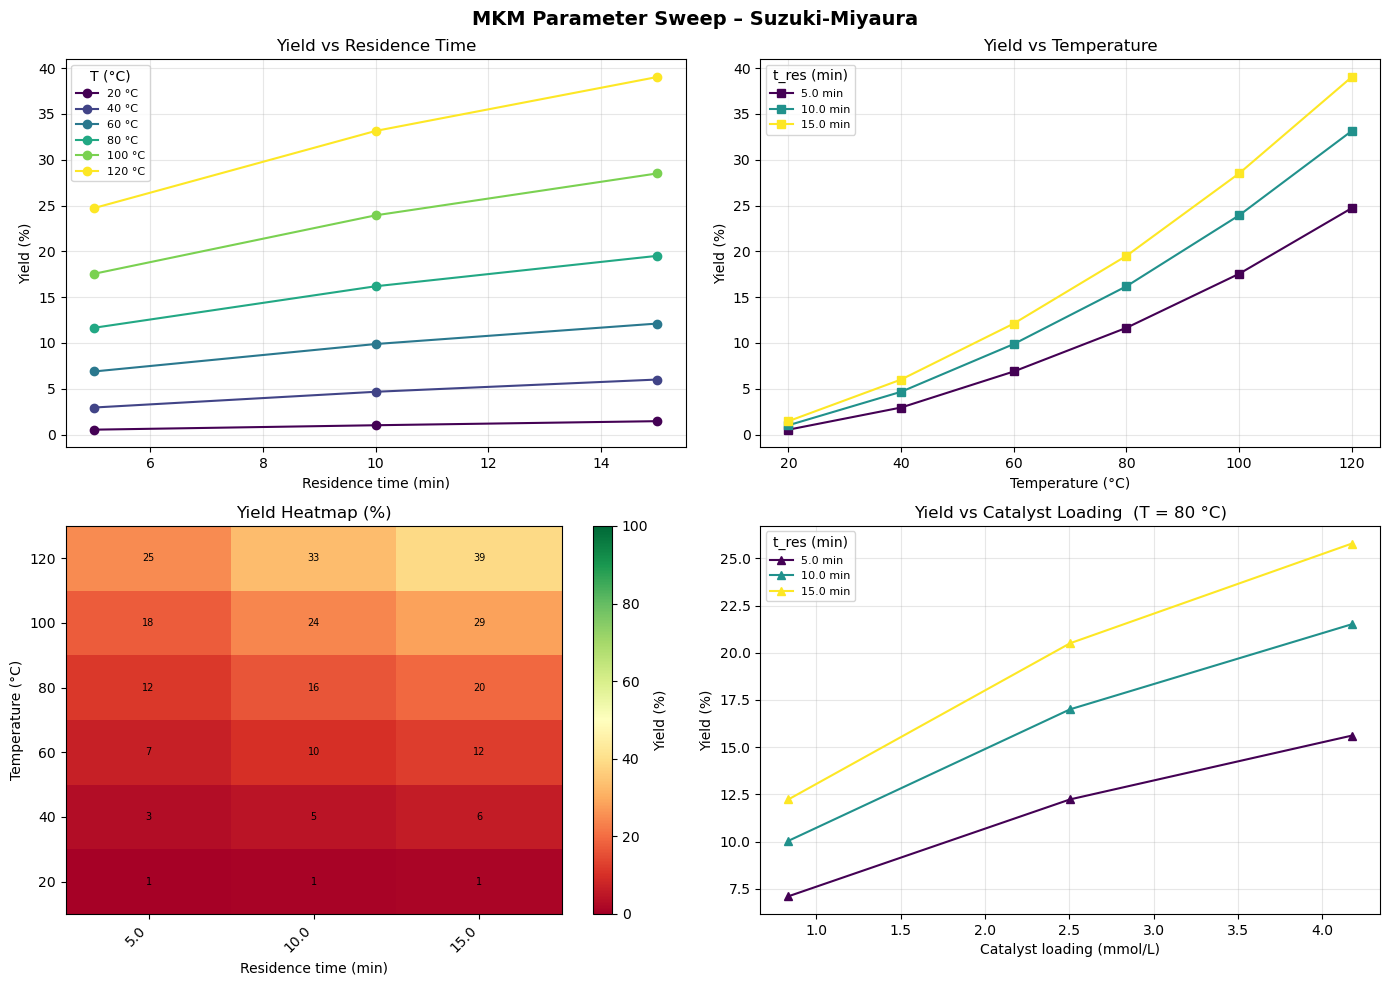

Plot saved → mkm_sweep_results_scipy.png


In [114]:
converged = results_df[results_df["converged"]].copy()
cmap = plt.cm.viridis

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("MKM Parameter Sweep – Suzuki-Miyaura", fontsize=14, fontweight="bold")

# Plot 1: Yield vs residence time
ax = axes[0, 0]
temps   = sorted(converged["T_C"].unique())
colours = cmap(np.linspace(0, 1, len(temps)))
for T, col in zip(temps, colours):
    sub = converged[converged["T_C"] == T]
    grp = sub.groupby("t_res_min")["yield_pct"].mean().reset_index()
    ax.plot(grp["t_res_min"], grp["yield_pct"], marker="o", color=col, label=f"{T} °C")
ax.set_xlabel("Residence time (min)")
ax.set_ylabel("Yield (%)")
ax.set_title("Yield vs Residence Time")
ax.legend(title="T (°C)", fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 2: Yield vs temperature
ax = axes[0, 1]
t_vals   = sorted(converged["t_res_min"].unique())
colours2 = cmap(np.linspace(0, 1, len(t_vals)))
for t, col in zip(t_vals, colours2):
    sub = converged[converged["t_res_min"] == t]
    grp = sub.groupby("T_C")["yield_pct"].mean().reset_index()
    ax.plot(grp["T_C"], grp["yield_pct"], marker="s", color=col, label=f"{t} min")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Yield (%)")
ax.set_title("Yield vs Temperature")
ax.legend(title="t_res (min)", fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 3: Yield heatmap
ax = axes[1, 0]
pivot = (converged
         .groupby(["T_C", "t_res_min"])["yield_pct"]
         .mean()
         .unstack("t_res_min"))
im = ax.imshow(pivot.values, aspect="auto", origin="lower",
               cmap="RdYlGn", vmin=0, vmax=100)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"{v:.1f}" for v in pivot.columns], rotation=45, ha="right")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("Residence time (min)")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Yield Heatmap (%)")
plt.colorbar(im, ax=ax, label="Yield (%)")
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7)

# Plot 4: Catalyst loading effect
ax = axes[1, 1]
ref_T    = sorted(converged["T_C"].unique())[len(converged["T_C"].unique()) // 2]
sub      = converged[converged["T_C"] == ref_T]
t_vals2  = sorted(sub["t_res_min"].unique())
colours3 = cmap(np.linspace(0, 1, len(t_vals2)))
for t, col in zip(t_vals2, colours3):
    grp = sub[sub["t_res_min"] == t].sort_values("cat_loading_M")
    ax.plot(grp["cat_loading_M"] * 1000, grp["yield_pct"],
            marker="^", color=col, label=f"{t} min")
ax.set_xlabel("Catalyst loading (mmol/L)")
ax.set_ylabel("Yield (%)")
ax.set_title(f"Yield vs Catalyst Loading  (T = {ref_T} °C)")
ax.legend(title="t_res (min)", fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("mkm_sweep_results_scipy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved → mkm_sweep_results_scipy.png")

## 10 · Inspect top conditions

In [137]:
print("═" * 55)
print("  Top 10 conditions by yield")
print("═" * 55)
print(
    results_df.nlargest(10, "yield_pct")[
        ["T_C", "t_res_min", "cat_loading_M", "yield_pct",
         "conv_halide_pct", "conv_boron_pct", "selectivity_pct"]
    ].reset_index(drop=True)
)

print("\nDescriptive statistics (converged runs only):")
print(
    results_df[results_df["converged"]][
        ["yield_pct", "conv_halide_pct", "conv_boron_pct", "selectivity_pct"]
    ].describe().round(2)
)

═══════════════════════════════════════════════════════
  Top 10 conditions by yield
═══════════════════════════════════════════════════════
   T_C  t_res_min  cat_loading_M  yield_pct  conv_halide_pct  conv_boron_pct  \
0  120       15.0       0.004175    50.0169          52.5169         33.4113   
1  120       10.0       0.004175    42.8319          45.3319         28.6117   
2  120       15.0       0.002505    41.0902          42.5902         27.4483   
3  100       15.0       0.004175    37.1033          39.6033         24.7850   
4  120       10.0       0.002505    34.8737          36.3737         23.2956   
5  120        5.0       0.004175    32.3272          34.8272         21.5946   
6  100       10.0       0.004175    31.3536          33.8536         20.9442   
7  100       15.0       0.002505    29.9821          31.4821         20.0280   
8  120        5.0       0.002505    25.9828          27.4828         17.3565   
9  120       15.0       0.000835    25.9828          26.482

## 11 · Concentration profiles — single-condition diagnostic

Run one simulation and plot every species over time. Used in combination with manual energy barrier changes to proof validations and to test at different conditions.

dG_rxn_xto0 at 70°C: -1326426.9214 kcal/mol
dG_xto0_fwd: 20.0000
dG_xto0_rev: 1326466.4214


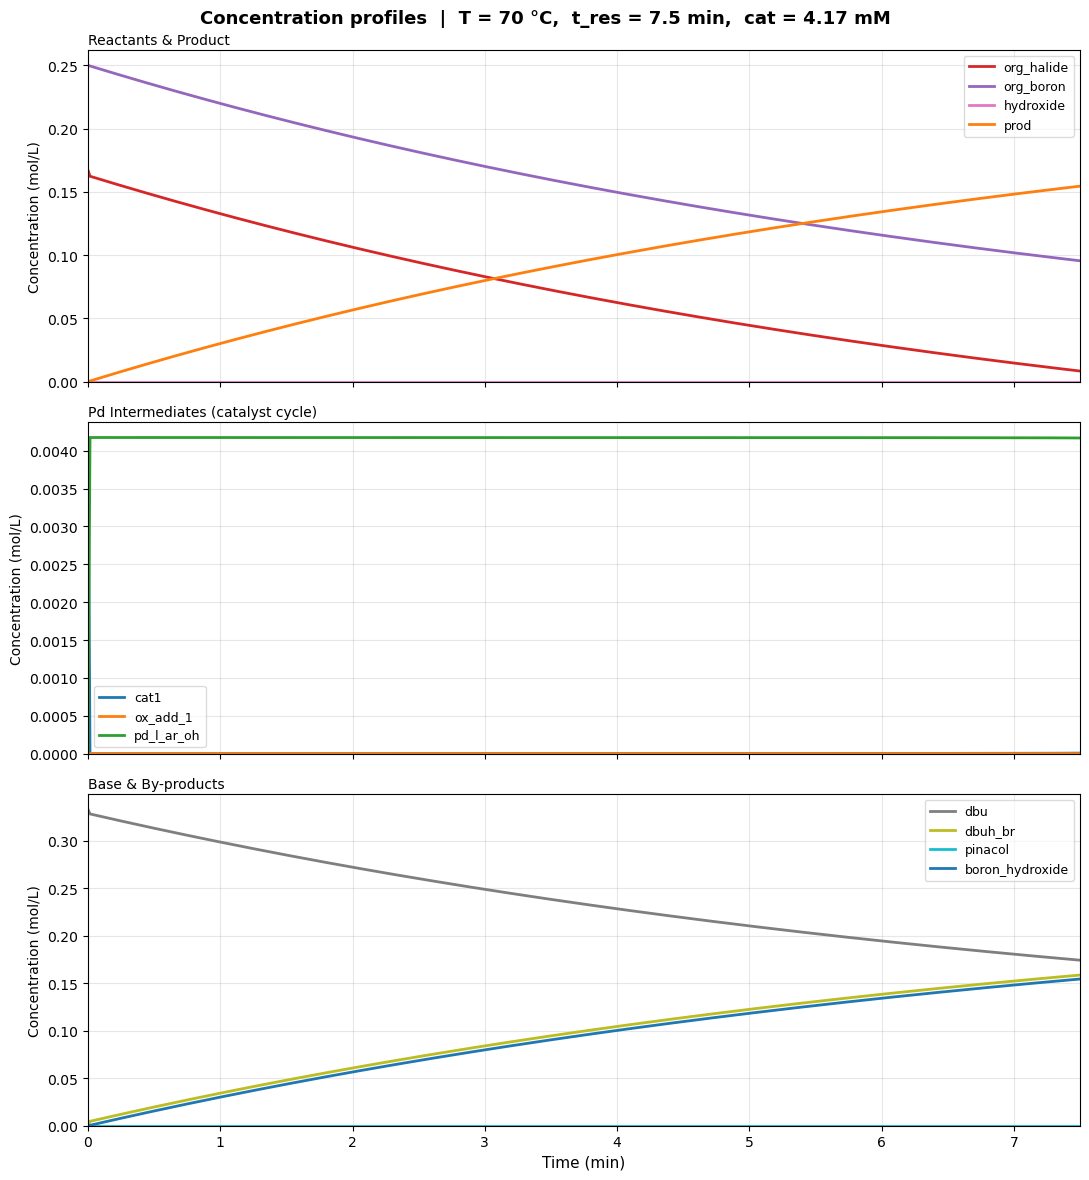

Plot saved → concentration_profiles_scipy.png

Mass-balance check:
  Pd total drift   (max |ΣPd − cat₀|)  : 1.82e-14 mol/L  ✓
  Aryl total drift (max |ΣAr − ArX₀|)  : 1.82e-14 mol/L  ✓

Final concentrations at t = 7.5 min:
  Species                C_final (mol/L)    % of initial
  ------------------------------------------------------
  cat1                          0.000007            0.2%
  ox_add_1                      0.000000               —
  pd_l_ar_oh                    0.004168               —
  org_halide                    0.008333            5.0%
  org_boron                     0.095500           38.2%
  water                         9.341333           98.3%
  hydroxide                     0.000000               —
  dbu                           0.174333           52.4%
  dbuh_br                       0.158667               —
  pinacol                       0.000000               —
  boron_hydroxide               0.154500               —
  prod                          0.15

In [7]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  SETTINGS – edit here                                            ║
# ╚══════════════════════════════════════════════════════════════════╝
PLOT_T_C       = 70
PLOT_T_RES_MIN = 7.5
PLOT_CAT_M     = 0.004175
N_PLOT_POINTS  = 500       # points on the time axis for plotting (purely cosmetic)

PANEL_1 = ["org_halide", "org_boron", "hydroxide", "prod"]
PANEL_2 = ["cat1", "ox_add_1", "pd_l_ar_oh"]
PANEL_3 = ["dbu", "dbuh_br", "pinacol", "boron_hydroxide"]
# ══════════════════════════════════════════════════════════════════════

conc_init = {**BASE_CONC, "cat1": PLOT_CAT_M}
sol_plot, _ = simulate_reactor(PLOT_T_C, conc_init, PLOT_T_RES_MIN)

if sol_plot is None:
    print("⚠  Simulation did not converge for the chosen conditions.")
    print("   Try a lower temperature, longer residence time, or check your barriers.")
else:
    # Evaluate on a fine uniform grid using the dense output
    t_s   = np.linspace(0, PLOT_T_RES_MIN * 60, N_PLOT_POINTS)
    t_min = t_s / 60.0
    y_all = sol_plot.sol(t_s)   # shape (n_species, N_PLOT_POINTS)

    conc_profiles = {sp: y_all[sp_idx[sp]] for sp in species}

    palette  = plt.cm.tab10.colors
    sp_color = {sp: palette[i % 10] for i, sp in enumerate(species)}

    panels = [
        (PANEL_1, "Reactants & Product"),
        (PANEL_2, "Pd Intermediates (catalyst cycle)"),
        (PANEL_3, "Base & By-products"),
    ]

    fig, axes = plt.subplots(len(panels), 1, figsize=(11, 4 * len(panels)), sharex=True)
    fig.suptitle(
        f"Concentration profiles  |  T = {PLOT_T_C} °C,  "
        f"t_res = {PLOT_T_RES_MIN} min,  cat = {PLOT_CAT_M*1000:.2f} mM",
        fontsize=13, fontweight="bold"
    )

    for ax, (panel_species, panel_title) in zip(axes, panels):
        for sp in panel_species:
            ax.plot(t_min, conc_profiles[sp],
                    color=sp_color[sp], linewidth=2, label=sp)
        ax.set_ylabel("Concentration (mol/L)", fontsize=10)
        ax.set_title(panel_title, fontsize=10, loc="left", pad=4)
        ax.legend(fontsize=9, loc="best", framealpha=0.7)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, PLOT_T_RES_MIN)
        ax.set_ylim(bottom=0)

    axes[-1].set_xlabel("Time (min)", fontsize=11)
    plt.tight_layout()
    plt.savefig("concentration_profiles_scipy.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Plot saved → concentration_profiles_scipy.png")

    # Mass-balance check
    pd_species = ["cat1", "ox_add_1", "pd_l_ar_oh"]
    pd_total   = np.sum([conc_profiles[sp] for sp in pd_species], axis=0)
    pd_drift   = np.max(np.abs(pd_total - PLOT_CAT_M))

    ar_species = ["org_halide", "ox_add_1", "pd_l_ar_oh", "prod"]
    ar_init    = conc_init.get("org_halide", 0)
    ar_total   = np.sum([conc_profiles[sp] for sp in ar_species], axis=0)
    ar_drift   = np.max(np.abs(ar_total - ar_init))

    print(f"\nMass-balance check:")
    print(f"  Pd total drift   (max |ΣPd − cat₀|)  : {pd_drift:.2e} mol/L  "
          + ("✓" if pd_drift < 1e-6 else "⚠ check stoichiometry"))
    print(f"  Aryl total drift (max |ΣAr − ArX₀|)  : {ar_drift:.2e} mol/L  "
          + ("✓" if ar_drift < 1e-6 else "⚠ check stoichiometry"))

    print(f"\nFinal concentrations at t = {PLOT_T_RES_MIN} min:")
    print(f"  {'Species':<20}  {'C_final (mol/L)':>16}  {'% of initial':>14}")
    print("  " + "-" * 54)
    for sp in species:
        c_final = conc_profiles[sp][-1]
        c_init  = conc_init.get(sp, 0.0)
        pct     = f"{c_final / c_init * 100:.1f}%" if c_init > 0 else "—"
        print(f"  {sp:<20}  {c_final:>16.6f}  {pct:>14}")

    yield_pct = conc_profiles['prod'][-1] / conc_init.get('org_halide', 1) * 100
    print(f"\n  → Yield: {yield_pct:.1f}%")

### Figure for visualization
This figure was used for the visualization for on specific request to prove the working of the microkinetic model. They can easily be removed and are non related to the actual microkinetic model

dG_rxn_xto0 at 70°C: -1326426.9214 kcal/mol
dG_xto0_fwd: 20.0000
dG_xto0_rev: 1326466.4214


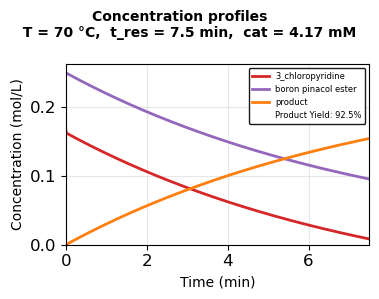

Plot saved → concentration_profiles_scipy.png

Mass-balance check:
  Pd total drift   (max |ΣPd − cat₀|)  : 1.82e-14 mol/L  ✓
  Aryl total drift (max |ΣAr − ArX₀|)  : 1.82e-14 mol/L  ✓

Final concentrations at t = 7.5 min:
  Species                C_final (mol/L)    % of initial
  ------------------------------------------------------
  cat1                          0.000007            0.2%
  ox_add_1                      0.000000               —
  pd_l_ar_oh                    0.004168               —
  3_chloropyridine              0.008333            5.0%
  boron pinacol ester           0.095500           38.2%
  water                         9.341333           98.3%
  hydroxide                     0.000000               —
  dbu                           0.174333           52.4%
  dbuh_br                       0.158667               —
  pinacol                       0.000000               —
  boron_hydroxide               0.154500               —
  product                       0.15

In [40]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  SETTINGS – edit here                                            ║
# ╚══════════════════════════════════════════════════════════════════╝
PLOT_T_C       = 70
PLOT_T_RES_MIN = 7.5
PLOT_CAT_M     = 0.004175
N_PLOT_POINTS  = 500       # points on the time axis for plotting (purely cosmetic)

PANEL_1 = ["org_halide", "org_boron", "prod"]
PANEL_2 = ["cat1", "ox_add_1", "pd_l_ar_oh"]
PANEL_3 = ["dbu", "dbuh_br", "pinacol", "boron_hydroxide"]
# ══════════════════════════════════════════════════════════════════════

# Define display names for legend
display_names = {
    "org_halide": "3_chloropyridine",
    "org_boron": "boron pinacol ester",
    "prod": "product"
}

conc_init = {**BASE_CONC, "cat1": PLOT_CAT_M}
sol_plot, _ = simulate_reactor(PLOT_T_C, conc_init, PLOT_T_RES_MIN)

if sol_plot is None:
    print("⚠  Simulation did not converge for the chosen conditions.")
    print("   Try a lower temperature, longer residence time, or check your barriers.")
else:
    # Evaluate on a fine uniform grid using the dense output
    t_s   = np.linspace(0, PLOT_T_RES_MIN * 60, N_PLOT_POINTS)
    t_min = t_s / 60.0
    y_all = sol_plot.sol(t_s)   # shape (n_species, N_PLOT_POINTS)

    conc_profiles = {sp: y_all[sp_idx[sp]] for sp in species}

    palette  = plt.cm.tab10.colors
    sp_color = {sp: palette[i % 10] for i, sp in enumerate(species)}

    # Calculate yield
    yield_pct = conc_profiles['prod'][-1] / conc_init.get('org_halide', 1) * 100

    # Plot only the first panel (Reactants & Product)
    fig, ax = plt.subplots(figsize=(4, 3))
    fig.suptitle(
        f"Concentration profiles  \n  T = {PLOT_T_C} °C,  "
        f"t_res = {PLOT_T_RES_MIN} min,  cat = {PLOT_CAT_M*1000:.2f} mM",
        fontsize=10, fontweight="bold"
    )

    # Plot species from PANEL_1 only
    for sp in PANEL_1:
        # Use display name if available, otherwise use species name
        label = display_names.get(sp, sp)
        ax.plot(t_min, conc_profiles[sp],
                color=sp_color[sp], linewidth=2, label=label)
    
    ax.set_ylabel("Concentration (mol/L)", fontsize=10)
    # ax.set_title("Reactants & Product", fontsize=10, loc="left", pad=4)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, PLOT_T_RES_MIN)
    ax.set_ylim(bottom=0)
    ax.set_xlabel("Time (min)", fontsize=10)
    
    # Create legend with yield included and thicker black border
    legend = ax.legend(fontsize=9, loc="best", framealpha=0.9, 
                       edgecolor='black')
    
    # Add yield text to the legend
    legend.get_frame().set_linewidth(1.5)
    legend.get_frame().set_edgecolor('black')
    
    # Add yield as a separate legend entry
    ax.plot([], [], ' ', label=f'Product Yield: {yield_pct:.1f}%')
    legend = ax.legend(fontsize=6, loc="best", framealpha=0.9, 
                       edgecolor='black')

    ax.tick_params(axis='both', labelsize=12) 
    plt.tight_layout()
    plt.savefig("concentration_profiles_scipy.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Plot saved → concentration_profiles_scipy.png")

    # Mass-balance check
    pd_species = ["cat1", "ox_add_1", "pd_l_ar_oh"]
    pd_total   = np.sum([conc_profiles[sp] for sp in pd_species], axis=0)
    pd_drift   = np.max(np.abs(pd_total - PLOT_CAT_M))

    ar_species = ["org_halide", "ox_add_1", "pd_l_ar_oh", "prod"]
    ar_init    = conc_init.get("org_halide", 0)
    ar_total   = np.sum([conc_profiles[sp] for sp in ar_species], axis=0)
    ar_drift   = np.max(np.abs(ar_total - ar_init))

    print(f"\nMass-balance check:")
    print(f"  Pd total drift   (max |ΣPd − cat₀|)  : {pd_drift:.2e} mol/L  "
          + ("✓" if pd_drift < 1e-6 else "⚠ check stoichiometry"))
    print(f"  Aryl total drift (max |ΣAr − ArX₀|)  : {ar_drift:.2e} mol/L  "
          + ("✓" if ar_drift < 1e-6 else "⚠ check stoichiometry"))

    print(f"\nFinal concentrations at t = {PLOT_T_RES_MIN} min:")
    print(f"  {'Species':<20}  {'C_final (mol/L)':>16}  {'% of initial':>14}")
    print("  " + "-" * 54)
    for sp in species:
        c_final = conc_profiles[sp][-1]
        c_init  = conc_init.get(sp, 0.0)
        pct     = f"{c_final / c_init * 100:.1f}%" if c_init > 0 else "—"
        # Use display name for printing if needed
        display_sp = display_names.get(sp, sp)
        print(f"  {display_sp:<20}  {c_final:>16.6f}  {pct:>14}")

    print(f"\n  → Yield: {yield_pct:.1f}%")

dG_rxn_xto0 at 70°C: -1326426.9214 kcal/mol
dG_xto0_fwd: 20.0000
dG_xto0_rev: 1326466.4214


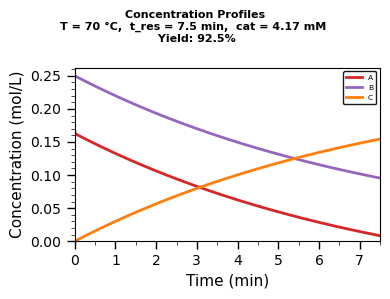

Plot saved → concentration_profiles_scipy.png

Mass-balance check:
  Pd total drift   (max |ΣPd − cat₀|)  : 1.82e-14 mol/L  ✓
  Aryl total drift (max |ΣAr − ArX₀|)  : 1.82e-14 mol/L  ✓

Final concentrations at t = 7.5 min:
  Species                C_final (mol/L)    % of initial
  ------------------------------------------------------
  cat1                          0.000007            0.2%
  ox_add_1                      0.000000               —
  pd_l_ar_oh                    0.004168               —
  A                             0.008333            5.0%
  B                             0.095500           38.2%
  water                         9.341333           98.3%
  hydroxide                     0.000000               —
  dbu                           0.174333           52.4%
  dbuh_br                       0.158667               —
  pinacol                       0.000000               —
  boron_hydroxide               0.154500               —
  C                             0.15

In [56]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  SETTINGS – edit here                                            ║
# ╚══════════════════════════════════════════════════════════════════╝
PLOT_T_C       = 70
PLOT_T_RES_MIN = 7.5
PLOT_CAT_M     = 0.004175
N_PLOT_POINTS  = 500       # points on the time axis for plotting (purely cosmetic)

PANEL_1 = ["org_halide", "org_boron", "prod"]
PANEL_2 = ["cat1", "ox_add_1", "pd_l_ar_oh"]
PANEL_3 = ["dbu", "dbuh_br", "pinacol", "boron_hydroxide"]
# ══════════════════════════════════════════════════════════════════════

# Define display names for legend
display_names = {
    "org_halide": "A",
    "org_boron": "B",
    "prod": "C"
}

conc_init = {**BASE_CONC, "cat1": PLOT_CAT_M}
sol_plot, _ = simulate_reactor(PLOT_T_C, conc_init, PLOT_T_RES_MIN)

if sol_plot is None:
    print("⚠  Simulation did not converge for the chosen conditions.")
    print("   Try a lower temperature, longer residence time, or check your barriers.")
else:
    # Evaluate on a fine uniform grid using the dense output
    t_s   = np.linspace(0, PLOT_T_RES_MIN * 60, N_PLOT_POINTS)
    t_min = t_s / 60.0
    y_all = sol_plot.sol(t_s)   # shape (n_species, N_PLOT_POINTS)

    conc_profiles = {sp: y_all[sp_idx[sp]] for sp in species}

    palette  = plt.cm.tab10.colors
    sp_color = {sp: palette[i % 10] for i, sp in enumerate(species)}

    # Calculate yield
    yield_pct = conc_profiles['prod'][-1] / conc_init.get('org_halide', 1) * 100

    # Plot only the first panel (Reactants & Product)
    fig, ax = plt.subplots(figsize=(4, 3))
    fig.suptitle(
        f"Concentration Profiles\nT = {PLOT_T_C} °C,  "
        f"t_res = {PLOT_T_RES_MIN} min,  cat = {PLOT_CAT_M*1000:.2f} mM \n Yield: {yield_pct:.1f}%",
        fontsize=8, fontweight="bold"
    )

    # Plot species from PANEL_1 only
    for sp in PANEL_1:
        # Use display name if available, otherwise use species name
        label = display_names.get(sp, sp)
        ax.plot(t_min, conc_profiles[sp],
                color=sp_color[sp], linewidth=2, label=label)
    
    ax.set_ylabel("Concentration (mol/L)", fontsize=11)
    ax.set_xlabel("Time (min)", fontsize=11)
    ax.grid(True, alpha=0)
    ax.set_xlim(0, PLOT_T_RES_MIN)
    ax.set_ylim(bottom=0)
    
    # Add more ticks on both axes
    from matplotlib.ticker import AutoMinorLocator, MultipleLocator
    
    # X-axis: major ticks every 1 minute, minor ticks every 0.5 minutes
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.xaxis.set_minor_locator(MultipleLocator(0.5))
    
    # Y-axis: let matplotlib choose nice major ticks, but add minor ticks
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))
    
    # Or specify custom tick intervals for y-axis (uncomment if you want fixed intervals)
    # ax.yaxis.set_major_locator(MultipleLocator(0.01))  # Adjust based on your concentration range
    # ax.yaxis.set_minor_locator(MultipleLocator(0.002))
    
    # Customize tick appearance
    ax.tick_params(axis='both', which='major', labelsize=10, width=1, length=6)
    ax.tick_params(axis='both', which='minor', width=0.5, length=3)
    
    # Create legend with yield included properly
    # First collect existing lines and labels
    lines = ax.get_lines()
    labels = [line.get_label() for line in lines]
    
    # Add yield as a separate legend entry
    yield_label = f'Product Yield: {yield_pct:.1f}%'
    
    # Create legend with yield included and thicker black border
    legend = ax.legend(lines + [ax.plot([], [], ' ')[0]], 
                      labels,
                      fontsize=5.5, loc="best", framealpha=0.9, 
                      edgecolor='black')

    plt.tight_layout()
    plt.savefig("ConcentrationProfile-Case2-70°C-4_3-FINAL.png", dpi=500, bbox_inches="tight")
    plt.show()
    print("Plot saved → concentration_profiles_scipy.png")

    # Mass-balance check
    pd_species = ["cat1", "ox_add_1", "pd_l_ar_oh"]
    pd_total   = np.sum([conc_profiles[sp] for sp in pd_species], axis=0)
    pd_drift   = np.max(np.abs(pd_total - PLOT_CAT_M))

    ar_species = ["org_halide", "ox_add_1", "pd_l_ar_oh", "prod"]
    ar_init    = conc_init.get("org_halide", 0)
    ar_total   = np.sum([conc_profiles[sp] for sp in ar_species], axis=0)
    ar_drift   = np.max(np.abs(ar_total - ar_init))

    print(f"\nMass-balance check:")
    print(f"  Pd total drift   (max |ΣPd − cat₀|)  : {pd_drift:.2e} mol/L  "
          + ("✓" if pd_drift < 1e-6 else "⚠ check stoichiometry"))
    print(f"  Aryl total drift (max |ΣAr − ArX₀|)  : {ar_drift:.2e} mol/L  "
          + ("✓" if ar_drift < 1e-6 else "⚠ check stoichiometry"))

    print(f"\nFinal concentrations at t = {PLOT_T_RES_MIN} min:")
    print(f"  {'Species':<20}  {'C_final (mol/L)':>16}  {'% of initial':>14}")
    print("  " + "-" * 54)
    for sp in species:
        c_final = conc_profiles[sp][-1]
        c_init  = conc_init.get(sp, 0.0)
        pct     = f"{c_final / c_init * 100:.1f}%" if c_init > 0 else "—"
        # Use display name for printing if needed
        display_sp = display_names.get(sp, sp)
        print(f"  {display_sp:<20}  {c_final:>16.6f}  {pct:>14}")

    print(f"\n  → Yield: {yield_pct:.1f}%")

## Manual Kinetics testing
The following code was used to quickly generate yield results based on reaction barriers for different elementary steps, such as hydroxide formation, x-to-o substitution, etc. They are in no means related to the overall microkinetic model and only serve the purpose of proving certain assumption in the master thesis. Therefore, they can easily be removed

### KINETICS: hydroxide formation


REACTION TEST: 25°C, t_res = 10 min
Forward barrier:  15.0 kcal/mol  →  k_fwd = 6.28e+01 s⁻¹
Reverse barrier:  14.8 kcal/mol  →  k_rev = 8.09e+01 s⁻¹
ΔG_rxn: 0.2 kcal/mol  →  Keq = 7.76e-01



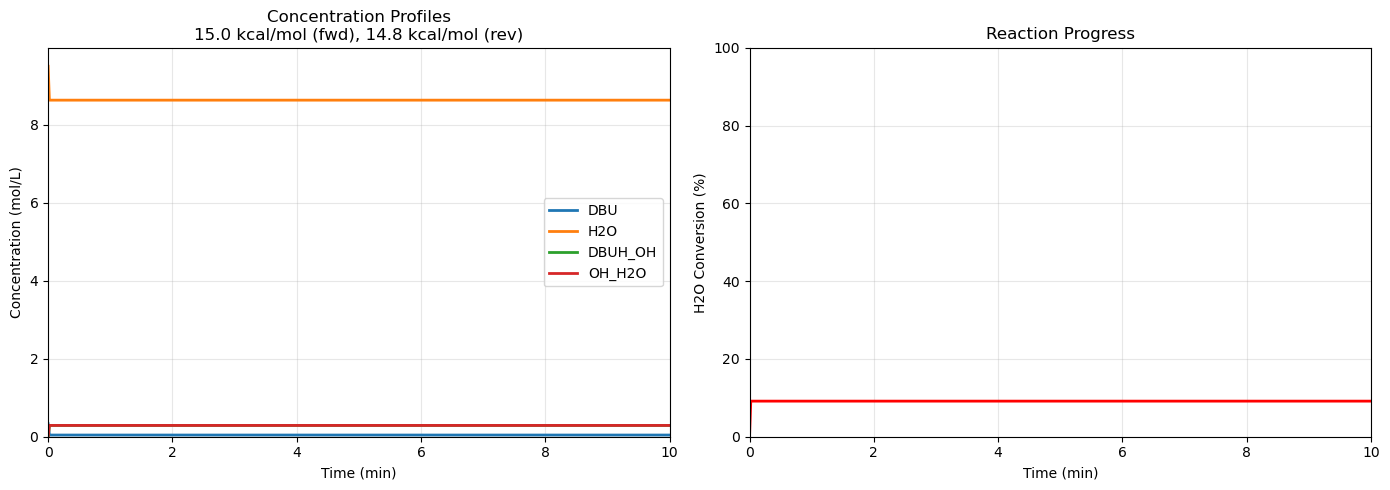


────────────────────────────────────────────────────────────
FINAL RESULTS at t = 10 min:
────────────────────────────────────────────────────────────
  DBU         : 0.043245 M  (13.0% of initial)
  H2O         : 8.630734 M  (90.8% of initial)
  DBUH_OH     : 0.289755 M
  OH_H2O      : 0.289755 M

  → H2O conversion: 9.15%


In [32]:
# =============================================================================
# NEW CELL: Quick Reaction Feasibility Test
# =============================================================================
"""
## Quick Reaction Feasibility Test

Use this cell to test individual reactions or small reaction networks.
You define your own reactants, products, and energy barriers.
The ODE solver will show concentration profiles and tell you if the reaction
proceeds under your chosen conditions.
"""

# ──────────────────────────────────────────────────────────────────────────
# STEP 1: DEFINE YOUR TEST REACTION(S)
# ──────────────────────────────────────────────────────────────────────────

# Example 1: DBU + H2O ⇌ DBUH_OH_contact
# ──────────────────────────────────────────────────────────────────────────
# Define species in your test system (order matters for plotting)
test_species = [
    "DBU",           # base
    "H2O",           # water
    "DBUH_OH",       # contact ion pair product
    "OH_H2O"
]

# Define forward and reverse reactions
# Each reaction: {rate_constant_name: [reactants], "stoichiometry": {species: coefficient}}
test_reactions = {
    "k_fwd": {
        "reactants": ["DBU", "H2O"],
        "stoich": {"DBU": -1, "H2O": -3, "DBUH_OH": 1, "OH_H2O": 1}
    },
    "k_rev": {
        "reactants": ["DBUH_OH"],
        "stoich": {"DBUH_OH": -1, "DBU": 1, "H2O": 3, "OH_H2O": -1}
    }
}

# Set YOUR energy barriers (kcal/mol)
# For a reversible reaction, dG_fwd and dG_rev determine the equilibrium
ΔG_fwd_kcal = 15.0   # Forward barrier (TS - reactants) — LOWER = FASTER
ΔG_rev_kcal = 14.85   # Reverse barrier (TS - products)

# Alternative: If you only know the equilibrium constant or ΔG_rxn:
# ΔG_rxn_kcal = ΔG_fwd_kcal - ΔG_rev_kcal (negative = spontaneous forward)

# Initial concentrations (mol/L)
test_initial = {
    "DBU": 0.333,      # typical DBU concentration
    "H2O": 9.5,        # water as solvent (approx 9.5 M in THF/water mixture)
    "DBUH_OH": 0.0,    # start with no product
    "OH_H2O": 0.0,     # start with no product
}

# ──────────────────────────────────────────────────────────────────────────
# STEP 2: RUN THE TEST
# ──────────────────────────────────────────────────────────────────────────

def test_reaction_system(T_C, t_res_min, initial_conc, reactions, ΔG_fwd, ΔG_rev):
    """
    Test a custom reaction system.
    
    Parameters:
    - T_C: temperature in °C
    - t_res_min: residence time in minutes
    - initial_conc: dict of initial concentrations
    - reactions: dict with 'k_fwd' and 'k_rev' keys, each containing 'reactants' and 'stoich'
    - ΔG_fwd, ΔG_rev: barriers in kcal/mol
    """
    
    T_K = T_C + 273.15
    
    # Calculate rate constants from Eyring equation
    def eyring_rate(deltaG_kcal, T_K):
        deltaG_J = deltaG_kcal * 4184.0
        k_B = 1.380649e-23
        h = 6.62607015e-34
        R = 8.3145
        return (k_B * T_K / h) * np.exp(-deltaG_J / (R * T_K))
    
    k_fwd = eyring_rate(ΔG_fwd, T_K)
    k_rev = eyring_rate(ΔG_rev, T_K)
    
    print(f"\n{'='*60}")
    print(f"REACTION TEST: {T_C}°C, t_res = {t_res_min} min")
    print(f"{'='*60}")
    print(f"Forward barrier:  {ΔG_fwd:.1f} kcal/mol  →  k_fwd = {k_fwd:.2e} s⁻¹")
    print(f"Reverse barrier:  {ΔG_rev:.1f} kcal/mol  →  k_rev = {k_rev:.2e} s⁻¹")
    
    ΔG_rxn = ΔG_fwd - ΔG_rev
    K_eq = np.exp(-ΔG_rxn * 4184.0 / (R * T_K))
    print(f"ΔG_rxn: {ΔG_rxn:.1f} kcal/mol  →  Keq = {K_eq:.2e}")
    print()
    
    # Build species list from initial_conc keys
    species_list = list(initial_conc.keys())
    sp_idx = {sp: i for i, sp in enumerate(species_list)}
    
    # Build stoichiometry matrix
    stoich_matrix = {}
    for rxn_name, rxn_info in reactions.items():
        stoich_matrix[rxn_name] = rxn_info["stoich"]
    
    # ODE function
    def test_odes(t, y, k_vals):
        y = np.maximum(y, 0.0)
        rates = {}
        
        # Forward reaction
        r = k_vals["k_fwd"]
        for sp in reactions["k_fwd"]["reactants"]:
            r *= y[sp_idx[sp]]
        rates["k_fwd"] = r
        
        # Reverse reaction
        r = k_vals["k_rev"]
        for sp in reactions["k_rev"]["reactants"]:
            r *= y[sp_idx[sp]]
        rates["k_rev"] = r
        
        dydt = np.zeros(len(species_list))
        for rxn_name, r in rates.items():
            for sp, coeff in stoich_matrix[rxn_name].items():
                dydt[sp_idx[sp]] += coeff * r
        
        return dydt
    
    # Initial conditions
    y0 = np.array([initial_conc.get(sp, 0.0) for sp in species_list])
    
    # Solve ODE
    t_span = (0.0, t_res_min * 60.0)
    k_vals = {"k_fwd": k_fwd, "k_rev": k_rev}
    
    sol = solve_ivp(
        test_odes,
        t_span=t_span,
        y0=y0,
        method="Radau",
        args=(k_vals,),
        rtol=1e-8,
        atol=1e-12,
        dense_output=True,
        max_step=1.0,
    )
    
    if not sol.success:
        print("❌ Integration failed!")
        return None
    
    # Generate plots
    t_s = np.linspace(0, t_res_min * 60, 500)
    t_min = t_s / 60.0
    y_all = sol.sol(t_s)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Concentration vs time
    colors = plt.cm.tab10.colors
    for i, sp in enumerate(species_list):
        ax1.plot(t_min, y_all[i], color=colors[i % 10], linewidth=2, label=sp)
    ax1.set_xlabel("Time (min)")
    ax1.set_ylabel("Concentration (mol/L)")
    ax1.set_title(f"Concentration Profiles\n{ΔG_fwd:.1f} kcal/mol (fwd), {ΔG_rev:.1f} kcal/mol (rev)")
    ax1.legend(loc="best")
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, t_res_min)
    ax1.set_ylim(bottom=0)
    
    # Plot 2: Fraction converted (for main reactant)
    # Find the main reactant (the one with highest initial concentration that decreases)
    main_reactant = None
    max_initial = 0
    for sp in species_list:
        c0 = initial_conc.get(sp, 0)
        if c0 > max_initial and sp in reactions["k_fwd"]["reactants"]:
            max_initial = c0
            main_reactant = sp
    
    if main_reactant:
        c0 = initial_conc.get(main_reactant, 0)
        conversion = (c0 - y_all[sp_idx[main_reactant]]) / c0 * 100
        ax2.plot(t_min, conversion, color='red', linewidth=2)
        ax2.set_xlabel("Time (min)")
        ax2.set_ylabel(f"{main_reactant} Conversion (%)")
        ax2.set_title("Reaction Progress")
        ax2.grid(True, alpha=0.3)
        ax2.set_xlim(0, t_res_min)
        ax2.set_ylim(0, 100)
    
    plt.tight_layout()
    plt.show()
    
    # Print final results
    print(f"\n{'─'*60}")
    print(f"FINAL RESULTS at t = {t_res_min} min:")
    print(f"{'─'*60}")
    for i, sp in enumerate(species_list):
        c_final = y_all[i, -1]
        c_init = initial_conc.get(sp, 0)
        if c_init > 0:
            pct = c_final / c_init * 100
            print(f"  {sp:<12}: {c_final:.6f} M  ({pct:.1f}% of initial)")
        else:
            print(f"  {sp:<12}: {c_final:.6f} M")
    
    if main_reactant:
        conv = (initial_conc.get(main_reactant, 0) - y_all[sp_idx[main_reactant], -1]) / initial_conc.get(main_reactant, 1) * 100
        print(f"\n  → {main_reactant} conversion: {conv:.2f}%")
    
    return sol


# ──────────────────────────────────────────────────────────────────────────
# QUICK TEST PARAMETERS (edit these)
# ──────────────────────────────────────────────────────────────────────────

TEST_TEMPERATURE_C = 25      # Reaction temperature (°C)
TEST_RESIDENCE_MIN = 10   # How long to run (minutes)

# Run the test!
sol = test_reaction_system(
    T_C=TEST_TEMPERATURE_C,
    t_res_min=TEST_RESIDENCE_MIN,
    initial_conc=test_initial,
    reactions=test_reactions,
    ΔG_fwd=ΔG_fwd_kcal,
    ΔG_rev=ΔG_rev_kcal
)


# ──────────────────────────────────────────────────────────────────────────
# BONUS: Quick screening over multiple barrier values
# ──────────────────────────────────────────────────────────────────────────

def scan_barriers(T_C, t_res_min, initial_conc, ΔG_fwd_list, ΔG_rev_fixed):
    """
    Scan different forward barriers to see when reaction becomes feasible.
    """
    results = []
    
    for ΔG_fwd in ΔG_fwd_list:
        T_K = T_C + 273.15
        R = 8.3145
        k_B = 1.380649e-23
        h = 6.62607015e-34
        
        k_fwd = (k_B * T_K / h) * np.exp(-ΔG_fwd * 4184.0 / (R * T_K))
        k_rev = (k_B * T_K / h) * np.exp(-ΔG_rev_fixed * 4184.0 / (R * T_K))
        
        # Find main reactant
        main_reactant = None
        for sp in initial_conc:
            if sp in ["DBU", "org_halide", "org_boron"]:
                main_reactant = sp
                break
        
        # Simple first-order approximation for screening
        # (full ODE would be better but slower)
        c0 = initial_conc.get(main_reactant, 0)
        t = t_res_min * 60
        
        # Solve simple ODE: dC/dt = -k_fwd * C (assuming excess water)
        c_final = c0 * np.exp(-k_fwd * t)
        conversion = (c0 - c_final) / c0 * 100
        
        results.append({
            "ΔG_fwd (kcal/mol)": ΔG_fwd,
            "k_fwd (s⁻¹)": k_fwd,
            "Conversion (%)": conversion,
            "Time constant (min)": 1/k_fwd/60 if k_fwd > 0 else float('inf')
        })
    
    results_df = pd.DataFrame(results)
    print(f"\n{'='*70}")
    print(f"BARRIER SCAN: {T_C}°C, t_res = {t_res_min} min")
    print(f"{'='*70}")
    print(results_df.to_string(index=False))
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(results_df["ΔG_fwd (kcal/mol)"], results_df["Conversion (%)"], 
            marker='o', linewidth=2, color='blue')
    ax.axhline(y=90, color='green', linestyle='--', alpha=0.7, label="90% conversion")
    ax.axhline(y=50, color='orange', linestyle='--', alpha=0.7, label="50% conversion")
    ax.set_xlabel("Forward Barrier (kcal/mol)")
    ax.set_ylabel(f"{main_reactant} Conversion (%)")
    ax.set_title(f"Reaction Feasibility at {T_C}°C after {t_res_min} min")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    return results_df


# Uncomment to run a barrier scan:
# ΔG_fwd_range = list(range(15, 41, 2))  # 15 to 40 kcal/mol in steps of 2
# scan_results = scan_barriers(
#     T_C=80,
#     t_res_min=60,
#     initial_conc=test_initial,
#     ΔG_fwd_list=ΔG_fwd_range,
#     ΔG_rev_fixed=20.0
# )

### KINETICS: X-to-O


REACTION TEST: 25°C, t_res = 10 min
Forward barrier:  15.0 kcal/mol  →  k_fwd = 6.28e+01 s⁻¹
Reverse barrier:  4.8 kcal/mol  →  k_rev = 1.98e+09 s⁻¹
ΔG_rxn: 10.2 kcal/mol  →  Keq = 3.17e-08



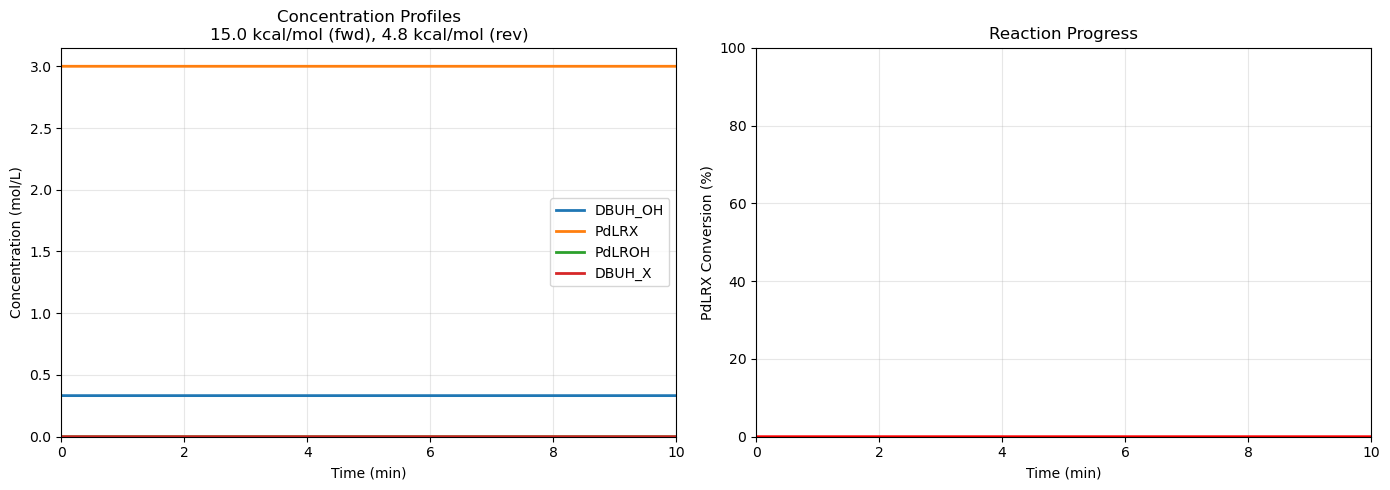


────────────────────────────────────────────────────────────
FINAL RESULTS at t = 10 min:
────────────────────────────────────────────────────────────
  DBUH_OH     : 0.332822 M  (99.9% of initial)
  PdLRX       : 2.999822 M  (100.0% of initial)
  PdLROH      : 0.000178 M
  DBUH_X      : 0.000178 M

  → PdLRX conversion: 0.01%


In [ ]:
# =============================================================================
# NEW CELL: Quick Reaction Feasibility Test
# =============================================================================
"""
## Quick Reaction Feasibility Test

Use this cell to test individual reactions or small reaction networks.
You define your own reactants, products, and energy barriers.
The ODE solver will show concentration profiles and tell you if the reaction
proceeds under your chosen conditions.
"""

# ──────────────────────────────────────────────────────────────────────────
# STEP 1: DEFINE YOUR TEST REACTION(S)
# ──────────────────────────────────────────────────────────────────────────

# Example 1: DBU + H2O ⇌ DBUH_OH_contact
# ──────────────────────────────────────────────────────────────────────────
# Define species in your test system (order matters for plotting)
test_species = [
    "DBUH_OH",           # base
    "PdLRX",           # water
    "PdLROH",       # contact ion pair product
    "DBUH_X"
]

# Define forward and reverse reactions
# Each reaction: {rate_constant_name: [reactants], "stoichiometry": {species: coefficient}}
test_reactions = {
    "k_fwd": {
        "reactants": ["DBUH_OH", "PdLRX"],
        "stoich": {"DBUH_OH": -1, "PdLRX": -1, "PdLROH": 1, "DBUH_X": 1}
    },
    "k_rev": {
        "reactants": ["DBUH_X", "PdLROH"],
        "stoich": {"DBUH_X": -1, "PdLROH": -1, "PdLRX": 1, "DBUH_OH": 1}
    }
}

# Set YOUR energy barriers (kcal/mol)
# For a reversible reaction, dG_fwd and dG_rev determine the equilibrium
ΔG_fwd_kcal = 15.0   # Forward barrier (TS - reactants) — LOWER = FASTER
ΔG_rev_kcal = 4.77   # Reverse barrier (TS - products)

# Alternative: If you only know the equilibrium constant or ΔG_rxn:
# ΔG_rxn_kcal = ΔG_fwd_kcal - ΔG_rev_kcal (negative = spontaneous forward)

# Initial concentrations (mol/L)
test_initial = {
    "DBUH_OH": 0.333,      # maximum DBU concentration
    "PdLRX": 3,        # maximum concentration of PdLRX possible (cat loading)
    "PdLROH": 0.0,    # start with no product
    "DBUH_X": 0.0,     # start with no product
}

# ──────────────────────────────────────────────────────────────────────────
# STEP 2: RUN THE TEST
# ──────────────────────────────────────────────────────────────────────────

def test_reaction_system(T_C, t_res_min, initial_conc, reactions, ΔG_fwd, ΔG_rev):
    """
    Test a custom reaction system.
    
    Parameters:
    - T_C: temperature in °C
    - t_res_min: residence time in minutes
    - initial_conc: dict of initial concentrations
    - reactions: dict with 'k_fwd' and 'k_rev' keys, each containing 'reactants' and 'stoich'
    - ΔG_fwd, ΔG_rev: barriers in kcal/mol
    """
    
    T_K = T_C + 273.15
    
    # Calculate rate constants from Eyring equation
    def eyring_rate(deltaG_kcal, T_K):
        deltaG_J = deltaG_kcal * 4184.0
        k_B = 1.380649e-23
        h = 6.62607015e-34
        R = 8.3145
        return (k_B * T_K / h) * np.exp(-deltaG_J / (R * T_K))
    
    k_fwd = eyring_rate(ΔG_fwd, T_K)
    k_rev = eyring_rate(ΔG_rev, T_K)
    
    print(f"\n{'='*60}")
    print(f"REACTION TEST: {T_C}°C, t_res = {t_res_min} min")
    print(f"{'='*60}")
    print(f"Forward barrier:  {ΔG_fwd:.1f} kcal/mol  →  k_fwd = {k_fwd:.2e} s⁻¹")
    print(f"Reverse barrier:  {ΔG_rev:.1f} kcal/mol  →  k_rev = {k_rev:.2e} s⁻¹")
    
    ΔG_rxn = ΔG_fwd - ΔG_rev
    K_eq = np.exp(-ΔG_rxn * 4184.0 / (R * T_K))
    print(f"ΔG_rxn: {ΔG_rxn:.1f} kcal/mol  →  Keq = {K_eq:.2e}")
    print()
    
    # Build species list from initial_conc keys
    species_list = list(initial_conc.keys())
    sp_idx = {sp: i for i, sp in enumerate(species_list)}
    
    # Build stoichiometry matrix
    stoich_matrix = {}
    for rxn_name, rxn_info in reactions.items():
        stoich_matrix[rxn_name] = rxn_info["stoich"]
    
    # ODE function
    def test_odes(t, y, k_vals):
        y = np.maximum(y, 0.0)
        rates = {}
        
        # Forward reaction
        r = k_vals["k_fwd"]
        for sp in reactions["k_fwd"]["reactants"]:
            r *= y[sp_idx[sp]]
        rates["k_fwd"] = r
        
        # Reverse reaction
        r = k_vals["k_rev"]
        for sp in reactions["k_rev"]["reactants"]:
            r *= y[sp_idx[sp]]
        rates["k_rev"] = r
        
        dydt = np.zeros(len(species_list))
        for rxn_name, r in rates.items():
            for sp, coeff in stoich_matrix[rxn_name].items():
                dydt[sp_idx[sp]] += coeff * r
        
        return dydt
    
    # Initial conditions
    y0 = np.array([initial_conc.get(sp, 0.0) for sp in species_list])
    
    # Solve ODE
    t_span = (0.0, t_res_min * 60.0)
    k_vals = {"k_fwd": k_fwd, "k_rev": k_rev}
    
    sol = solve_ivp(
        test_odes,
        t_span=t_span,
        y0=y0,
        method="Radau",
        args=(k_vals,),
        rtol=1e-8,
        atol=1e-12,
        dense_output=True,
        max_step=1.0,
    )
    
    if not sol.success:
        print("❌ Integration failed!")
        return None
    
    # Generate plots
    t_s = np.linspace(0, t_res_min * 60, 500)
    t_min = t_s / 60.0
    y_all = sol.sol(t_s)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Concentration vs time
    colors = plt.cm.tab10.colors
    for i, sp in enumerate(species_list):
        ax1.plot(t_min, y_all[i], color=colors[i % 10], linewidth=2, label=sp)
    ax1.set_xlabel("Time (min)")
    ax1.set_ylabel("Concentration (mol/L)")
    ax1.set_title(f"Concentration Profiles\n{ΔG_fwd:.1f} kcal/mol (fwd), {ΔG_rev:.1f} kcal/mol (rev)")
    ax1.legend(loc="best")
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, t_res_min)
    ax1.set_ylim(bottom=0)
    
    # Plot 2: Fraction converted (for main reactant)
    # Find the main reactant (the one with highest initial concentration that decreases)
    main_reactant = None
    max_initial = 0
    for sp in species_list:
        c0 = initial_conc.get(sp, 0)
        if c0 > max_initial and sp in reactions["k_fwd"]["reactants"]:
            max_initial = c0
            main_reactant = sp
    
    if main_reactant:
        c0 = initial_conc.get(main_reactant, 0)
        conversion = (c0 - y_all[sp_idx[main_reactant]]) / c0 * 100
        ax2.plot(t_min, conversion, color='red', linewidth=2)
        ax2.set_xlabel("Time (min)")
        ax2.set_ylabel(f"{main_reactant} Conversion (%)")
        ax2.set_title("Reaction Progress")
        ax2.grid(True, alpha=0.3)
        ax2.set_xlim(0, t_res_min)
        ax2.set_ylim(0, 100)
    
    plt.tight_layout()
    plt.show()
    
    # Print final results
    print(f"\n{'─'*60}")
    print(f"FINAL RESULTS at t = {t_res_min} min:")
    print(f"{'─'*60}")
    for i, sp in enumerate(species_list):
        c_final = y_all[i, -1]
        c_init = initial_conc.get(sp, 0)
        if c_init > 0:
            pct = c_final / c_init * 100
            print(f"  {sp:<12}: {c_final:.6f} M  ({pct:.1f}% of initial)")
        else:
            print(f"  {sp:<12}: {c_final:.6f} M")
    
    if main_reactant:
        conv = (initial_conc.get(main_reactant, 0) - y_all[sp_idx[main_reactant], -1]) / initial_conc.get(main_reactant, 1) * 100
        print(f"\n  → {main_reactant} conversion: {conv:.2f}%")
    
    return sol


# ──────────────────────────────────────────────────────────────────────────
# QUICK TEST PARAMETERS (edit these)
# ──────────────────────────────────────────────────────────────────────────

TEST_TEMPERATURE_C = 25      # Reaction temperature (°C)
TEST_RESIDENCE_MIN = 10   # How long to run (minutes)

# Run the test!
sol = test_reaction_system(
    T_C=TEST_TEMPERATURE_C,
    t_res_min=TEST_RESIDENCE_MIN,
    initial_conc=test_initial,
    reactions=test_reactions,
    ΔG_fwd=ΔG_fwd_kcal,
    ΔG_rev=ΔG_rev_kcal
)


# ──────────────────────────────────────────────────────────────────────────
# BONUS: Quick screening over multiple barrier values
# ──────────────────────────────────────────────────────────────────────────

def scan_barriers(T_C, t_res_min, initial_conc, ΔG_fwd_list, ΔG_rev_fixed):
    """
    Scan different forward barriers to see when reaction becomes feasible.
    """
    results = []
    
    for ΔG_fwd in ΔG_fwd_list:
        T_K = T_C + 273.15
        R = 8.3145
        k_B = 1.380649e-23
        h = 6.62607015e-34
        
        k_fwd = (k_B * T_K / h) * np.exp(-ΔG_fwd * 4184.0 / (R * T_K))
        k_rev = (k_B * T_K / h) * np.exp(-ΔG_rev_fixed * 4184.0 / (R * T_K))
        
        # Find main reactant
        main_reactant = None
        for sp in initial_conc:
            if sp in ["DBU", "org_halide", "org_boron"]:
                main_reactant = sp
                break
        
        # Simple first-order approximation for screening
        # (full ODE would be better but slower)
        c0 = initial_conc.get(main_reactant, 0)
        t = t_res_min * 60
        
        # Solve simple ODE: dC/dt = -k_fwd * C (assuming excess water)
        c_final = c0 * np.exp(-k_fwd * t)
        conversion = (c0 - c_final) / c0 * 100
        
        results.append({
            "ΔG_fwd (kcal/mol)": ΔG_fwd,
            "k_fwd (s⁻¹)": k_fwd,
            "Conversion (%)": conversion,
            "Time constant (min)": 1/k_fwd/60 if k_fwd > 0 else float('inf')
        })
    
    results_df = pd.DataFrame(results)
    print(f"\n{'='*70}")
    print(f"BARRIER SCAN: {T_C}°C, t_res = {t_res_min} min")
    print(f"{'='*70}")
    print(results_df.to_string(index=False))
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(results_df["ΔG_fwd (kcal/mol)"], results_df["Conversion (%)"], 
            marker='o', linewidth=2, color='blue')
    ax.axhline(y=90, color='green', linestyle='--', alpha=0.7, label="90% conversion")
    ax.axhline(y=50, color='orange', linestyle='--', alpha=0.7, label="50% conversion")
    ax.set_xlabel("Forward Barrier (kcal/mol)")
    ax.set_ylabel(f"{main_reactant} Conversion (%)")
    ax.set_title(f"Reaction Feasibility at {T_C}°C after {t_res_min} min")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    return results_df


# Uncomment to run a barrier scan:
# ΔG_fwd_range = list(range(15, 41, 2))  # 15 to 40 kcal/mol in steps of 2
# scan_results = scan_barriers(
#     T_C=80,
#     t_res_min=60,
#     initial_conc=test_initial,
#     ΔG_fwd_list=ΔG_fwd_range,
#     ΔG_rev_fixed=20.0
# )

### KINETICS: X-to-O adjusted


REACTION TEST: DBUH_OH + PdLRX ⇌ PdLROH + DBUH_X
Temperature:     110°C
Residence time:  10 min
----------------------------------------------------------------------
Forward barrier:  15.0 kcal/mol  →  k_fwd = 2.22e+04 s⁻¹
Reverse barrier:  14.4 kcal/mol  →  k_rev = 4.88e+04 s⁻¹
ΔG_rxn:          0.6 kcal/mol  →  Keq = 4.55e-01
PdLRX half-life: ~0.0 min (with excess DBUH_OH)



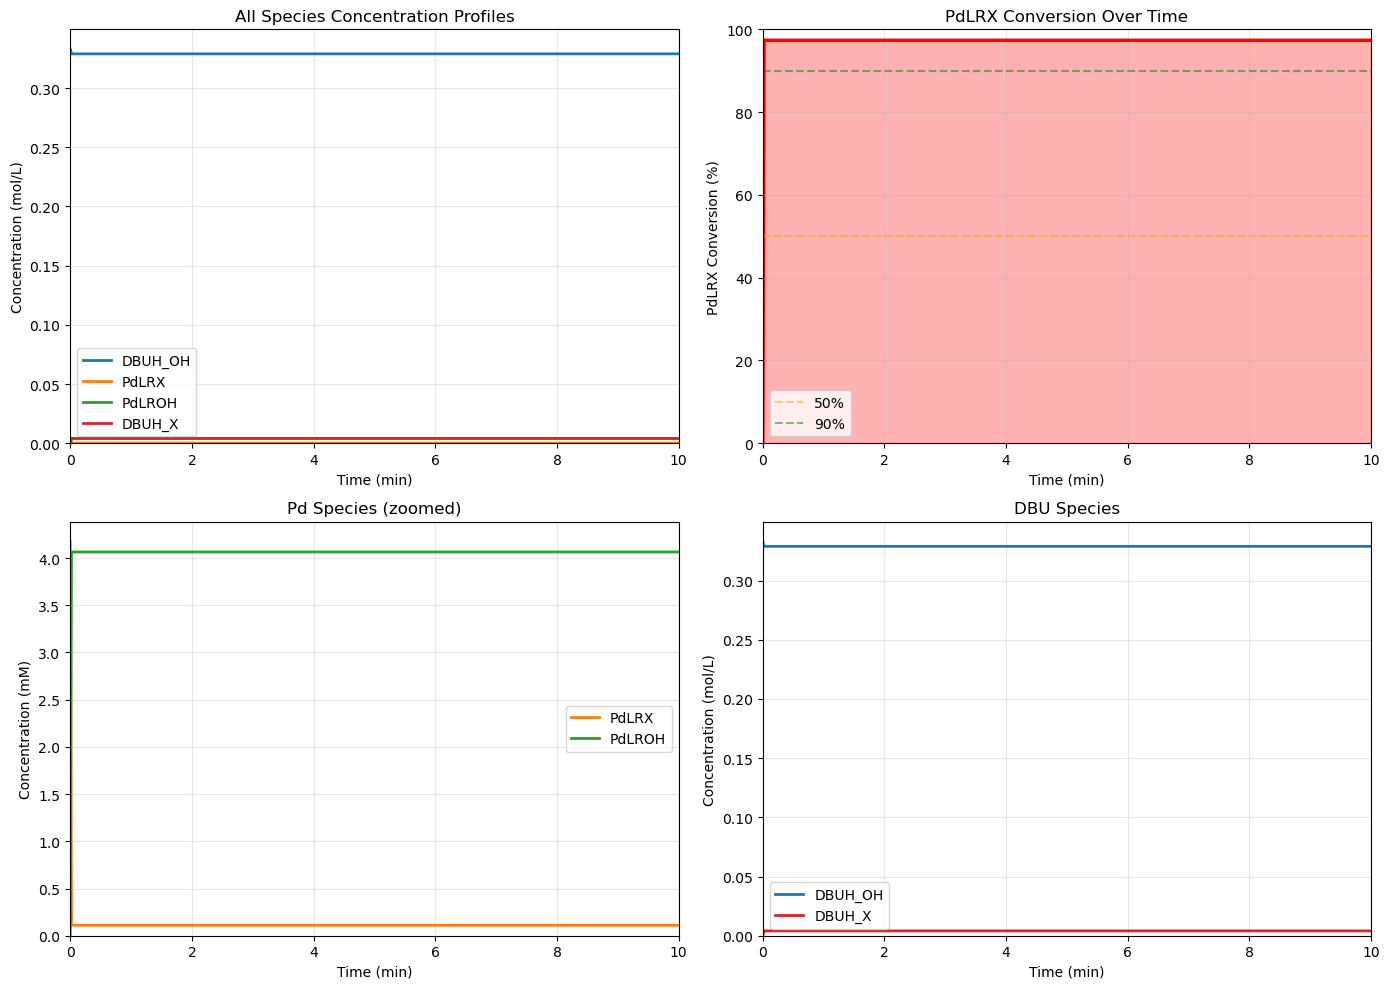


──────────────────────────────────────────────────────────────────────
FINAL RESULTS at t = 10 min:
──────────────────────────────────────────────────────────────────────
  DBUH_OH     : 0.328935 M  (98.8% of initial)
  ⭐ PdLRX     : 0.000110 M  (2.6% remaining → 97.4% converted)
  PdLROH      : 0.004065 M  (formed)
  DBUH_X      : 0.004065 M  (formed)

⭐ PdLRX CONVERSION: 97.355% after 10 minutes
  Final Qc = 4.547e-01  |  Keq = 4.547e-01
  → Reaction reached equilibrium ✓


In [61]:
# =============================================================================
# NEW CELL: Quick Reaction Feasibility Test - PdLRX Conversion
# =============================================================================
"""
## Quick Reaction Feasibility Test for: DBUH_OH + PdLRX ⇌ PdLROH + DBUH_X
"""

# ──────────────────────────────────────────────────────────────────────────
# STEP 1: DEFINE YOUR TEST REACTION(S)
# ──────────────────────────────────────────────────────────────────────────

# Define species in your test system
test_species = [
    "DBUH_OH",    # protonated DBU + OH (contact ion pair)
    "PdLRX",      # Pd complex with aryl halide (your limiting reagent)
    "PdLROH",     # Pd complex with OH (product)
    "DBUH_X"      # DBU-H with halide counterion
]

# Define forward and reverse reactions
test_reactions = {
    "k_fwd": {
        "reactants": ["DBUH_OH", "PdLRX"],
        "stoich": {"DBUH_OH": -1, "PdLRX": -1, "PdLROH": 1, "DBUH_X": 1}
    },
    "k_rev": {
        "reactants": ["DBUH_X", "PdLROH"],
        "stoich": {"DBUH_X": -1, "PdLROH": -1, "PdLRX": 1, "DBUH_OH": 1}
    }
}

# ──────────────────────────────────────────────────────────────────────────
# SET YOUR ENERGY BARRIERS (kcal/mol) - EDIT THESE!
# ──────────────────────────────────────────────────────────────────────────
ΔG_fwd_kcal = 15   # Forward barrier: DBUH_OH + PdLRX → TS → products
ΔG_rev_kcal = 14.4   # Reverse barrier: DBUH_X + PdLROH → TS → reactants 6.34 4.77

# ──────────────────────────────────────────────────────────────────────────
# INITIAL CONCENTRATIONS (mol/L) - EDIT AS NEEDED
# ──────────────────────────────────────────────────────────────────────────
test_initial = {
    "DBUH_OH": 0.333,      # DBU concentration (excess, ~0.333 M typical)
    "PdLRX": 0.004175,     # Pd catalyst loading (your limiting reagent!)
    "PdLROH": 0.0,         # start with no product
    "DBUH_X": 0.0,         # start with no product
}

# ──────────────────────────────────────────────────────────────────────────
# TEST CONDITIONS - EDIT THESE
# ──────────────────────────────────────────────────────────────────────────
TEST_TEMPERATURE_C = 110     # Reaction temperature (°C)
TEST_RESIDENCE_MIN = 10     # How long to run (minutes)

# ──────────────────────────────────────────────────────────────────────────
# STEP 2: RUN THE TEST (no changes needed below)
# ──────────────────────────────────────────────────────────────────────────

def test_reaction_system(T_C, t_res_min, initial_conc, reactions, ΔG_fwd, ΔG_rev):
    """
    Test a custom reaction system with clear PdLRX conversion tracking.
    """
    
    T_K = T_C + 273.15
    
    # Calculate rate constants from Eyring equation
    def eyring_rate(deltaG_kcal, T_K):
        deltaG_J = deltaG_kcal * 4184.0
        k_B = 1.380649e-23
        h = 6.62607015e-34
        R = 8.3145
        return (k_B * T_K / h) * np.exp(-deltaG_J / (R * T_K))
    
    k_fwd = eyring_rate(ΔG_fwd, T_K)
    k_rev = eyring_rate(ΔG_rev, T_K)
    
    print(f"\n{'='*70}")
    print(f"REACTION TEST: DBUH_OH + PdLRX ⇌ PdLROH + DBUH_X")
    print(f"{'='*70}")
    print(f"Temperature:     {T_C}°C")
    print(f"Residence time:  {t_res_min} min")
    print(f"{'-'*70}")
    print(f"Forward barrier:  {ΔG_fwd:.1f} kcal/mol  →  k_fwd = {k_fwd:.2e} s⁻¹")
    print(f"Reverse barrier:  {ΔG_rev:.1f} kcal/mol  →  k_rev = {k_rev:.2e} s⁻¹")
    
    ΔG_rxn = ΔG_fwd - ΔG_rev
    R = 8.3145
    K_eq = np.exp(-ΔG_rxn * 4184.0 / (R * T_K))
    print(f"ΔG_rxn:          {ΔG_rxn:.1f} kcal/mol  →  Keq = {K_eq:.2e}")
    
    # Estimate half-life for PdLRX (assuming excess DBUH_OH)
    k_eff = k_fwd * initial_conc.get("DBUH_OH", 0)
    if k_eff > 0:
        t_half_min = np.log(2) / k_eff / 60
        print(f"PdLRX half-life: ~{t_half_min:.1f} min (with excess DBUH_OH)")
    print()
    
    # Build species list from initial_conc keys
    species_list = list(initial_conc.keys())
    sp_idx = {sp: i for i, sp in enumerate(species_list)}
    
    # Build stoichiometry matrix
    stoich_matrix = {}
    for rxn_name, rxn_info in reactions.items():
        stoich_matrix[rxn_name] = rxn_info["stoich"]
    
    # ODE function
    def test_odes(t, y, k_vals):
        y = np.maximum(y, 0.0)
        rates = {}
        
        # Forward reaction
        r = k_vals["k_fwd"]
        for sp in reactions["k_fwd"]["reactants"]:
            r *= y[sp_idx[sp]]
        rates["k_fwd"] = r
        
        # Reverse reaction
        r = k_vals["k_rev"]
        for sp in reactions["k_rev"]["reactants"]:
            r *= y[sp_idx[sp]]
        rates["k_rev"] = r
        
        dydt = np.zeros(len(species_list))
        for rxn_name, r in rates.items():
            for sp, coeff in stoich_matrix[rxn_name].items():
                dydt[sp_idx[sp]] += coeff * r
        
        return dydt
    
    # Initial conditions
    y0 = np.array([initial_conc.get(sp, 0.0) for sp in species_list])
    
    # Solve ODE
    t_span = (0.0, t_res_min * 60.0)
    k_vals = {"k_fwd": k_fwd, "k_rev": k_rev}
    
    sol = solve_ivp(
        test_odes,
        t_span=t_span,
        y0=y0,
        method="Radau",
        args=(k_vals,),
        rtol=1e-8,
        atol=1e-12,
        dense_output=True,
        max_step=1.0,
    )
    
    if not sol.success:
        print("❌ Integration failed!")
        return None
    
    # Generate plots
    t_s = np.linspace(0, t_res_min * 60, 500)
    t_min = t_s / 60.0
    y_all = sol.sol(t_s)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: All concentrations vs time
    ax1 = axes[0, 0]
    colors = plt.cm.tab10.colors
    for i, sp in enumerate(species_list):
        ax1.plot(t_min, y_all[i], color=colors[i % 10], linewidth=2, label=sp)
    ax1.set_xlabel("Time (min)")
    ax1.set_ylabel("Concentration (mol/L)")
    ax1.set_title("All Species Concentration Profiles")
    ax1.legend(loc="best")
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, t_res_min)
    ax1.set_ylim(bottom=0)
    
    # Plot 2: PdLRX conversion specifically (THIS IS WHAT YOU WANT!)
    ax2 = axes[0, 1]
    c0_PdLRX = initial_conc.get("PdLRX", 0)
    if c0_PdLRX > 0:
        conversion_PdLRX = (c0_PdLRX - y_all[sp_idx["PdLRX"]]) / c0_PdLRX * 100
        ax2.plot(t_min, conversion_PdLRX, color='red', linewidth=2.5)
        ax2.fill_between(t_min, conversion_PdLRX, alpha=0.3, color='red')
        ax2.set_xlabel("Time (min)")
        ax2.set_ylabel("PdLRX Conversion (%)")
        ax2.set_title("PdLRX Conversion Over Time")
        ax2.grid(True, alpha=0.3)
        ax2.set_xlim(0, t_res_min)
        ax2.set_ylim(0, 100)
        # Add 50% and 90% reference lines
        ax2.axhline(y=50, color='orange', linestyle='--', alpha=0.5, label="50%")
        ax2.axhline(y=90, color='green', linestyle='--', alpha=0.5, label="90%")
        ax2.legend()
    
    # Plot 3: Zoom on Pd species (since they're at low concentration)
    ax3 = axes[1, 0]
    for sp in ["PdLRX", "PdLROH"]:
        if sp in species_list:
            i = sp_idx[sp]
            ax3.plot(t_min, y_all[i] * 1000, color=colors[i % 10], linewidth=2, label=sp)
    ax3.set_xlabel("Time (min)")
    ax3.set_ylabel("Concentration (mM)")
    ax3.set_title("Pd Species (zoomed)")
    ax3.legend(loc="best")
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim(0, t_res_min)
    ax3.set_ylim(bottom=0)
    
    # Plot 4: DBU species
    ax4 = axes[1, 1]
    for sp in ["DBUH_OH", "DBUH_X"]:
        if sp in species_list:
            i = sp_idx[sp]
            ax4.plot(t_min, y_all[i], color=colors[i % 10], linewidth=2, label=sp)
    ax4.set_xlabel("Time (min)")
    ax4.set_ylabel("Concentration (mol/L)")
    ax4.set_title("DBU Species")
    ax4.legend(loc="best")
    ax4.grid(True, alpha=0.3)
    ax4.set_xlim(0, t_res_min)
    ax4.set_ylim(bottom=0)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed results
    print(f"\n{'─'*70}")
    print(f"FINAL RESULTS at t = {t_res_min} min:")
    print(f"{'─'*70}")
    
    for i, sp in enumerate(species_list):
        c_final = y_all[i, -1]
        c_init = initial_conc.get(sp, 0)
        if c_init > 0:
            pct = c_final / c_init * 100
            if sp == "PdLRX":
                print(f"  ⭐ {sp:<10}: {c_final:.6f} M  ({pct:.1f}% remaining → {100-pct:.1f}% converted)")
            else:
                print(f"  {sp:<12}: {c_final:.6f} M  ({pct:.1f}% of initial)")
        else:
            print(f"  {sp:<12}: {c_final:.6f} M  (formed)")
    
    # PdLRX conversion summary
    if c0_PdLRX > 0:
        conv_final = (c0_PdLRX - y_all[sp_idx["PdLRX"], -1]) / c0_PdLRX * 100
        print(f"\n{'='*70}")
        print(f"⭐ PdLRX CONVERSION: {conv_final:.3f}% after {t_res_min} minutes")
        
        # Check if reaction reached equilibrium
        final_ratio = (y_all[sp_idx["PdLROH"], -1] * y_all[sp_idx["DBUH_X"], -1]) / \
                      (y_all[sp_idx["DBUH_OH"], -1] * y_all[sp_idx["PdLRX"], -1] + 1e-12)
        print(f"  Final Qc = {final_ratio:.3e}  |  Keq = {K_eq:.3e}")
        if abs(final_ratio / K_eq - 1) < 0.05:
            print("  → Reaction reached equilibrium ✓")
        elif final_ratio < K_eq:
            print("  → Still proceeding forward (not yet at equilibrium)")
        else:
            print("  → At or past equilibrium")
        print(f"{'='*70}")
    
    return sol


# ──────────────────────────────────────────────────────────────────────────
# RUN THE TEST
# ──────────────────────────────────────────────────────────────────────────

sol = test_reaction_system(
    T_C=TEST_TEMPERATURE_C,
    t_res_min=TEST_RESIDENCE_MIN,
    initial_conc=test_initial,
    reactions=test_reactions,
    ΔG_fwd=ΔG_fwd_kcal,
    ΔG_rev=ΔG_rev_kcal
)


# ──────────────────────────────────────────────────────────────────────────
# BONUS: Scan over different forward barriers for PdLRX conversion
# ──────────────────────────────────────────────────────────────────────────

def scan_pdlrx_conversion(T_C, t_res_min, initial_conc, ΔG_fwd_list, ΔG_rev_fixed):
    """
    Scan different forward barriers to see when PdLRX conversion becomes feasible.
    """
    results = []
    R = 8.3145
    k_B = 1.380649e-23
    h = 6.62607015e-15  # eV·s, but using J·s: 6.626e-34
    h = 6.62607015e-34   # correct J·s
    
    for ΔG_fwd in ΔG_fwd_list:
        T_K = T_C + 273.15
        
        k_fwd = (k_B * T_K / h) * np.exp(-ΔG_fwd * 4184.0 / (R * T_K))
        k_rev = (k_B * T_K / h) * np.exp(-ΔG_rev_fixed * 4184.0 / (R * T_K))
        
        # Effective rate with excess DBUH_OH (pseudo-first order)
        c_DBUH_OH = initial_conc.get("DBUH_OH", 0.333)
        k_eff = k_fwd * c_DBUH_OH
        t_half_min = np.log(2) / k_eff / 60 if k_eff > 0 else float('inf')
        
        # Estimate conversion at given time using first-order approximation
        t_sec = t_res_min * 60
        conversion_approx = (1 - np.exp(-k_eff * t_sec)) * 100
        
        results.append({
            "ΔG_fwd (kcal/mol)": ΔG_fwd,
            "k_fwd (s⁻¹)": f"{k_fwd:.2e}",
            "t₁/₂ (min)": f"{t_half_min:.1f}" if t_half_min < 1e6 else ">1e6",
            "Est. Conversion (%)": f"{conversion_approx:.1f}",
            "Feasible?": "✓" if conversion_approx > 80 else ("~" if conversion_approx > 20 else "✗")
        })
    
    results_df = pd.DataFrame(results)
    print(f"\n{'='*80}")
    print(f"BARRIER SCAN for PdLRX Conversion")
    print(f"Conditions: {T_C}°C, t_res = {t_res_min} min, [DBUH_OH] = {initial_conc.get('DBUH_OH', 0.333):.3f} M")
    print(f"Reverse barrier fixed at {ΔG_rev_fixed:.1f} kcal/mol")
    print(f"{'='*80}")
    print(results_df.to_string(index=False))
    
    # Plot conversion vs barrier
    fig, ax = plt.subplots(figsize=(10, 6))
    conv_values = [float(r["Est. Conversion (%)"]) for r in results]
    ax.plot(ΔG_fwd_list, conv_values, marker='o', linewidth=2, color='blue', markersize=8)
    ax.axhline(y=90, color='green', linestyle='--', linewidth=2, alpha=0.7, label="90% conversion (practical complete)")
    ax.axhline(y=50, color='orange', linestyle='--', linewidth=2, alpha=0.7, label="50% conversion")
    ax.fill_between(ΔG_fwd_list, conv_values, 90, where=(np.array(conv_values) >= 90), 
                    color='green', alpha=0.2, label="Feasible region")
    ax.fill_between(ΔG_fwd_list, conv_values, 90, where=(np.array(conv_values) < 90), 
                    color='red', alpha=0.1, label="Not feasible")
    ax.set_xlabel("Forward Barrier (kcal/mol)", fontsize=12)
    ax.set_ylabel("Estimated PdLRX Conversion (%)", fontsize=12)
    ax.set_title(f"PdLRX Conversion vs Barrier Energy\n{T_C}°C, {t_res_min} min residence time", fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    
    # Find the maximum feasible barrier
    max_feasible = None
    for i, conv in enumerate(conv_values):
        if conv >= 80:
            max_feasible = ΔG_fwd_list[i]
    if max_feasible:
        ax.axvline(x=max_feasible, color='purple', linestyle=':', alpha=0.7)
        ax.text(max_feasible + 0.5, 50, f"Max feasible barrier\n~{max_feasible} kcal/mol", 
                fontsize=10, color='purple')
    
    plt.tight_layout()
    plt.show()
    
    return results_df


# Uncomment to run a barrier scan:
# print("\n" + "="*80)
# print("RUNNING BARRIER SCAN...")
# print("="*80)
# ΔG_fwd_range = list(range(10, 36, 2))  # 10 to 34 kcal/mol
# scan_results = scan_pdlrx_conversion(
#     T_C=80,
#     t_res_min=30,
#     initial_conc=test_initial,
#     ΔG_fwd_list=ΔG_fwd_range,
#     ΔG_rev_fixed=4.77
# )

### KINETICS: boronate pathway


TWO-STEP REACTION TEST
Temperature:     25°C
Residence time:  10 min
--------------------------------------------------------------------------------
REACTION 1: R2BOH2 + DBU_H_OH ⇌ DBU_H_R2BOH3
  Forward barrier:  15.0 kcal/mol  →  k1_fwd = 6.28e+01 s⁻¹
  Reverse barrier:  12.2 kcal/mol  →  k1_rev = 7.71e+03 s⁻¹
  ΔG1_rxn:         2.8 kcal/mol  →  Keq1 = 8.15e-03

REACTION 2: PdLR1X + DBU_H_R2BOH3 ⇌ PdLR1R2BOH3 + DBU_H_X
  Forward barrier:  5.0 kcal/mol  →  k2_fwd = 1.34e+09 s⁻¹
  Reverse barrier:  14.2 kcal/mol  →  k2_rev = 2.30e+02 s⁻¹
  ΔG2_rxn:         -9.2 kcal/mol  →  Keq2 = 5.83e+06

Estimated time scales:
  Step 1 half-life: ~0.0 min (assuming R2BOH2 + DBU_H_OH excess)
  Step 2 half-life: ~0.0 min (at typical concentrations)



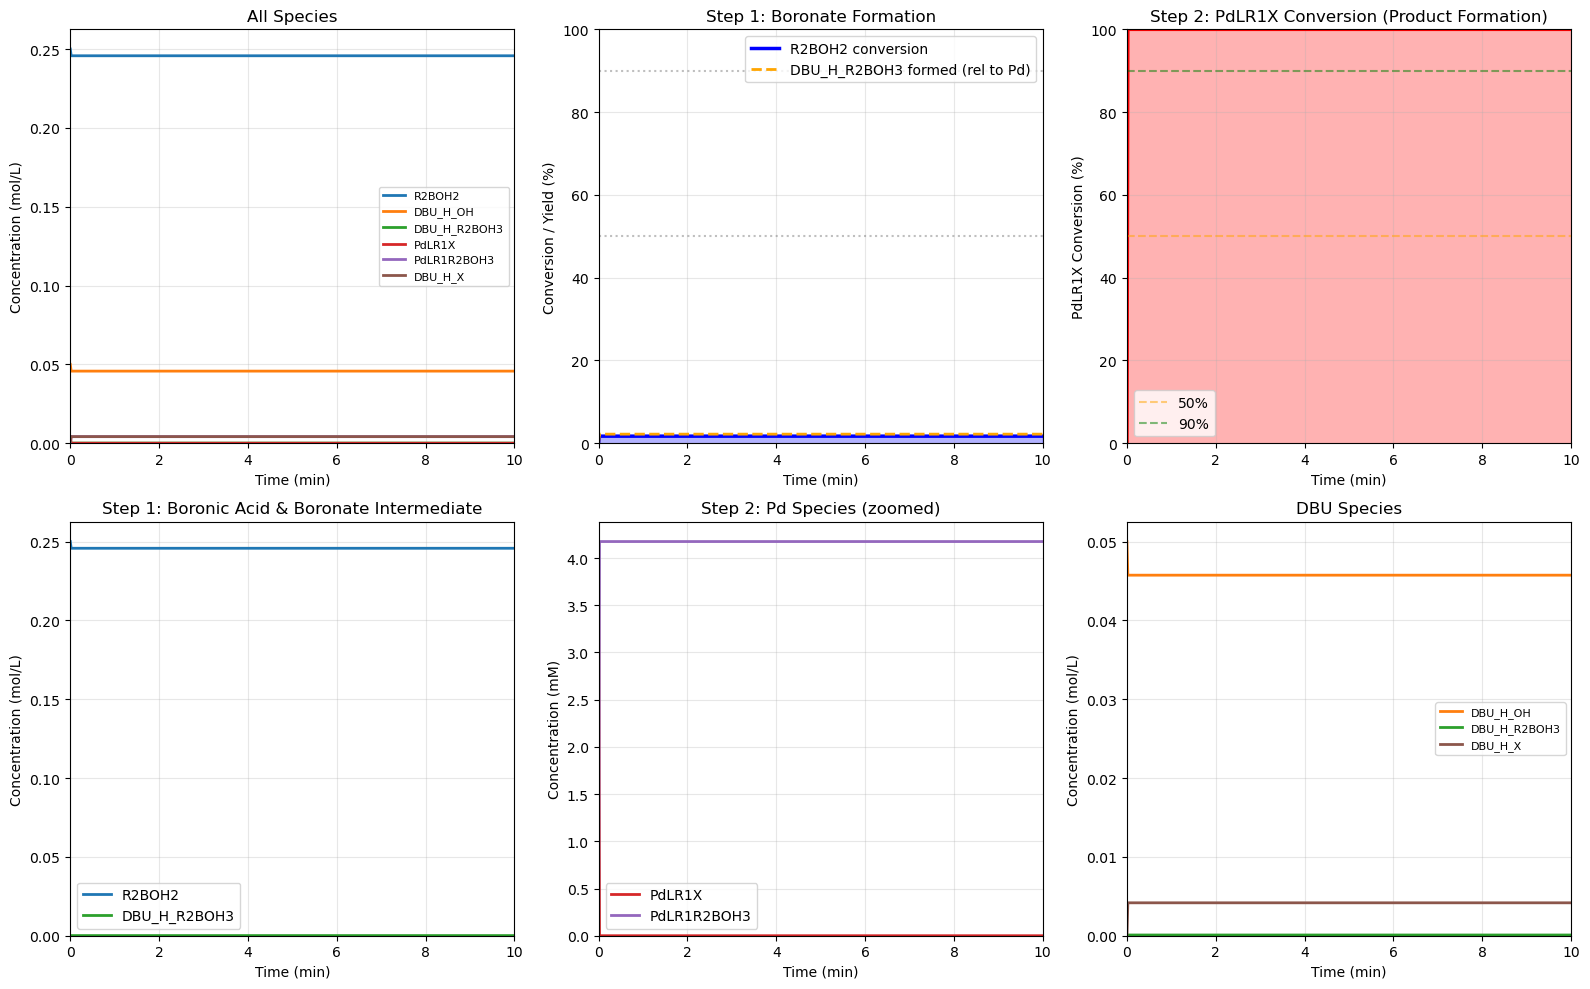


────────────────────────────────────────────────────────────────────────────────
FINAL RESULTS at t = 10 min:
────────────────────────────────────────────────────────────────────────────────
  R2BOH2        : 0.245733 M  (98.3% of initial)
  DBU_H_OH      : 0.045733 M  (91.5% of initial)
  DBU_H_R2BOH3  : 0.000092 M  (formed)
  ⭐ PdLR1X        : 0.000000 M  (0.0% remaining → 100.0% converted)
  PdLR1R2BOH3   : 0.004175 M  (formed)
  DBU_H_X       : 0.004175 M  (formed)

STEP 1 - BORONATE FORMATION:
  R2BOH2 conversion: 1.7%
  DBU_H_R2BOH3 yield: 0.0% (relative to R2BOH2)

⭐ STEP 2 - TRANSMETALATION (MAIN RESULT):
  PdLR1X conversion: 100.0%
  Product (PdLR1R2BOH3) yield: 100.0%
  Final Qc = 4.368e+06  |  Keq2 = 5.829e+06
  → Step 2 still proceeding forward


In [65]:
# =============================================================================
# NEW CELL: Quick Reaction Feasibility Test - Two-Step Boronate Formation & Transmetalation
# =============================================================================
"""
## Quick Reaction Feasibility Test for:
    (1) R2BOH2 + DBU_H_OH ⇌ DBU_H_R2BOH3
    (2) PdLR1X + DBU_H_R2BOH3 ⇌ PdLR1R2BOH3 + DBU_H_X
"""

# ──────────────────────────────────────────────────────────────────────────
# STEP 1: DEFINE YOUR TEST REACTION(S)
# ──────────────────────────────────────────────────────────────────────────

# Define species in your test system (order matters for plotting)
test_species = [
    "R2BOH2",           # Boronic acid (reactant)
    "DBU_H_OH",         # DBU-H-OH contact ion pair
    "DBU_H_R2BOH3",     # Boronate intermediate (product of step 1, reactant for step 2)
    "PdLR1X",           # Pd complex with aryl halide (limiting reagent for step 2)
    "PdLR1R2BOH3",      # Pd complex with coupled product (final product)
    "DBU_H_X"           # DBU-H-X salt (byproduct)
]

# Define forward and reverse reactions for BOTH steps
test_reactions = {
    # Reaction 1: Boronic acid activation
    "k1_fwd": {
        "reactants": ["R2BOH2", "DBU_H_OH"],
        "stoich": {"R2BOH2": -1, "DBU_H_OH": -1, "DBU_H_R2BOH3": 1}
    },
    "k1_rev": {
        "reactants": ["DBU_H_R2BOH3"],
        "stoich": {"DBU_H_R2BOH3": -1, "R2BOH2": 1, "DBU_H_OH": 1}
    },
    # Reaction 2: Transmetalation
    "k2_fwd": {
        "reactants": ["PdLR1X", "DBU_H_R2BOH3"],
        "stoich": {"PdLR1X": -1, "DBU_H_R2BOH3": -1, "PdLR1R2BOH3": 1, "DBU_H_X": 1}
    },
    "k2_rev": {
        "reactants": ["PdLR1R2BOH3", "DBU_H_X"],
        "stoich": {"PdLR1R2BOH3": -1, "DBU_H_X": -1, "PdLR1X": 1, "DBU_H_R2BOH3": 1}
    }
}

# ──────────────────────────────────────────────────────────────────────────
# SET YOUR ENERGY BARRIERS (kcal/mol) - EDIT THESE!
# ──────────────────────────────────────────────────────────────────────────
# Reaction 1: R2BOH2 + DBU_H_OH ⇌ DBU_H_R2BOH3
ΔG1_fwd_kcal = 15.0    # Forward barrier for boronate formation
ΔG1_rev_kcal = 12.15    # Reverse barrier for boronate formation

# Reaction 2: PdLR1X + DBU_H_R2BOH3 ⇌ PdLR1R2BOH3 + DBU_H_X
ΔG2_fwd_kcal = 5    # Forward barrier for transmetalation
ΔG2_rev_kcal = 14.23    # Reverse barrier for transmetalation

# ──────────────────────────────────────────────────────────────────────────
# INITIAL CONCENTRATIONS (mol/L) - EDIT AS NEEDED
# ──────────────────────────────────────────────────────────────────────────
test_initial = {
    "R2BOH2": 0.25,          # Boronic acid (excess, ~0.25 M typical)
    "DBU_H_OH": 0.05,       # DBU-H-OH concentration
    "DBU_H_R2BOH3": 0.0,     # Start with no intermediate
    "PdLR1X": 0.004175,      # Pd catalyst loading (limiting reagent!)
    "PdLR1R2BOH3": 0.0,      # Start with no product
    "DBU_H_X": 0.0,          # Start with no byproduct
}

# ──────────────────────────────────────────────────────────────────────────
# TEST CONDITIONS - EDIT THESE
# ──────────────────────────────────────────────────────────────────────────
TEST_TEMPERATURE_C = 25      # Reaction temperature (°C)
TEST_RESIDENCE_MIN = 10      # How long to run (minutes)

# ──────────────────────────────────────────────────────────────────────────
# STEP 2: RUN THE TEST (no changes needed below)
# ──────────────────────────────────────────────────────────────────────────

def test_two_step_reaction(T_C, t_res_min, initial_conc, reactions, 
                           ΔG1_fwd, ΔG1_rev, ΔG2_fwd, ΔG2_rev):
    """
    Test a two-step reaction sequence with clear tracking of both steps.
    """
    
    T_K = T_C + 273.15
    
    # Calculate rate constants from Eyring equation
    def eyring_rate(deltaG_kcal, T_K):
        deltaG_J = deltaG_kcal * 4184.0
        k_B = 1.380649e-23
        h = 6.62607015e-34
        R = 8.3145
        return (k_B * T_K / h) * np.exp(-deltaG_J / (R * T_K))
    
    k1_fwd = eyring_rate(ΔG1_fwd, T_K)
    k1_rev = eyring_rate(ΔG1_rev, T_K)
    k2_fwd = eyring_rate(ΔG2_fwd, T_K)
    k2_rev = eyring_rate(ΔG2_rev, T_K)
    
    print(f"\n{'='*80}")
    print(f"TWO-STEP REACTION TEST")
    print(f"{'='*80}")
    print(f"Temperature:     {T_C}°C")
    print(f"Residence time:  {t_res_min} min")
    print(f"{'-'*80}")
    
    # Reaction 1 info
    print(f"REACTION 1: R2BOH2 + DBU_H_OH ⇌ DBU_H_R2BOH3")
    print(f"  Forward barrier:  {ΔG1_fwd:.1f} kcal/mol  →  k1_fwd = {k1_fwd:.2e} s⁻¹")
    print(f"  Reverse barrier:  {ΔG1_rev:.1f} kcal/mol  →  k1_rev = {k1_rev:.2e} s⁻¹")
    ΔG1_rxn = ΔG1_fwd - ΔG1_rev
    R = 8.3145
    K1_eq = np.exp(-ΔG1_rxn * 4184.0 / (R * T_K))
    print(f"  ΔG1_rxn:         {ΔG1_rxn:.1f} kcal/mol  →  Keq1 = {K1_eq:.2e}")
    
    # Reaction 2 info
    print(f"\nREACTION 2: PdLR1X + DBU_H_R2BOH3 ⇌ PdLR1R2BOH3 + DBU_H_X")
    print(f"  Forward barrier:  {ΔG2_fwd:.1f} kcal/mol  →  k2_fwd = {k2_fwd:.2e} s⁻¹")
    print(f"  Reverse barrier:  {ΔG2_rev:.1f} kcal/mol  →  k2_rev = {k2_rev:.2e} s⁻¹")
    ΔG2_rxn = ΔG2_fwd - ΔG2_rev
    K2_eq = np.exp(-ΔG2_rxn * 4184.0 / (R * T_K))
    print(f"  ΔG2_rxn:         {ΔG2_rxn:.1f} kcal/mol  →  Keq2 = {K2_eq:.2e}")
    
    # Estimate rate-limiting step
    c_R2BOH2 = initial_conc.get("R2BOH2", 0.25)
    c_DBU_H_OH = initial_conc.get("DBU_H_OH", 0.333)
    k1_eff = k1_fwd * c_R2BOH2 * c_DBU_H_OH
    k2_eff_pseudo = k2_fwd * initial_conc.get("DBU_H_R2BOH3", 0) if initial_conc.get("DBU_H_R2BOH3", 0) > 0 else k2_fwd * 0.1
    print(f"\nEstimated time scales:")
    if k1_eff > 0:
        t1_half_min = np.log(2) / k1_eff / 60 if k1_eff > 0 else float('inf')
        print(f"  Step 1 half-life: ~{t1_half_min:.1f} min (assuming R2BOH2 + DBU_H_OH excess)")
    if k2_fwd > 0:
        t2_half_min_est = np.log(2) / (k2_fwd * initial_conc.get("PdLR1X", 0.004)) / 60
        print(f"  Step 2 half-life: ~{t2_half_min_est:.1f} min (at typical concentrations)")
    print()
    
    # Build species list from initial_conc keys
    species_list = list(initial_conc.keys())
    sp_idx = {sp: i for i, sp in enumerate(species_list)}
    
    # Build stoichiometry matrix
    stoich_matrix = {}
    for rxn_name, rxn_info in reactions.items():
        stoich_matrix[rxn_name] = rxn_info["stoich"]
    
    # ODE function
    def test_odes(t, y, k_vals):
        y = np.maximum(y, 0.0)
        rates = {}
        
        # Reaction 1 forward
        r = k_vals["k1_fwd"]
        for sp in reactions["k1_fwd"]["reactants"]:
            r *= y[sp_idx[sp]]
        rates["k1_fwd"] = r
        
        # Reaction 1 reverse
        r = k_vals["k1_rev"]
        for sp in reactions["k1_rev"]["reactants"]:
            r *= y[sp_idx[sp]]
        rates["k1_rev"] = r
        
        # Reaction 2 forward
        r = k_vals["k2_fwd"]
        for sp in reactions["k2_fwd"]["reactants"]:
            r *= y[sp_idx[sp]]
        rates["k2_fwd"] = r
        
        # Reaction 2 reverse
        r = k_vals["k2_rev"]
        for sp in reactions["k2_rev"]["reactants"]:
            r *= y[sp_idx[sp]]
        rates["k2_rev"] = r
        
        dydt = np.zeros(len(species_list))
        for rxn_name, r in rates.items():
            for sp, coeff in stoich_matrix[rxn_name].items():
                dydt[sp_idx[sp]] += coeff * r
        
        return dydt
    
    # Initial conditions
    y0 = np.array([initial_conc.get(sp, 0.0) for sp in species_list])
    
    # Solve ODE
    t_span = (0.0, t_res_min * 60.0)
    k_vals = {"k1_fwd": k1_fwd, "k1_rev": k1_rev, "k2_fwd": k2_fwd, "k2_rev": k2_rev}
    
    sol = solve_ivp(
        test_odes,
        t_span=t_span,
        y0=y0,
        method="Radau",
        args=(k_vals,),
        rtol=1e-8,
        atol=1e-12,
        dense_output=True,
        max_step=1.0,
    )
    
    if not sol.success:
        print("❌ Integration failed!")
        return None
    
    # Generate plots
    t_s = np.linspace(0, t_res_min * 60, 500)
    t_min = t_s / 60.0
    y_all = sol.sol(t_s)
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    
    colors = plt.cm.tab10.colors
    
    # Plot 1: All concentrations vs time
    ax1 = axes[0, 0]
    for i, sp in enumerate(species_list):
        ax1.plot(t_min, y_all[i], color=colors[i % 10], linewidth=2, label=sp)
    ax1.set_xlabel("Time (min)")
    ax1.set_ylabel("Concentration (mol/L)")
    ax1.set_title("All Species")
    ax1.legend(loc="best", fontsize=8)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, t_res_min)
    ax1.set_ylim(bottom=0)
    
    # Plot 2: Step 1 - Boronate formation
    ax2 = axes[0, 1]
    c0_R2BOH2 = initial_conc.get("R2BOH2", 0)
    if c0_R2BOH2 > 0:
        conv_R2BOH2 = (c0_R2BOH2 - y_all[sp_idx["R2BOH2"]]) / c0_R2BOH2 * 100
        ax2.plot(t_min, conv_R2BOH2, color='blue', linewidth=2.5, label="R2BOH2 conversion")
        ax2.fill_between(t_min, conv_R2BOH2, alpha=0.3, color='blue')
    ax2.plot(t_min, y_all[sp_idx["DBU_H_R2BOH3"]] / initial_conc.get("PdLR1X", 0.004) * 100, 
             color='orange', linewidth=2, linestyle='--', label="DBU_H_R2BOH3 formed (rel to Pd)")
    ax2.set_xlabel("Time (min)")
    ax2.set_ylabel("Conversion / Yield (%)")
    ax2.set_title("Step 1: Boronate Formation")
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, t_res_min)
    ax2.set_ylim(0, 100)
    ax2.legend()
    ax2.axhline(y=50, color='gray', linestyle=':', alpha=0.5)
    ax2.axhline(y=90, color='gray', linestyle=':', alpha=0.5)
    
    # Plot 3: PdLR1X conversion (THIS IS WHAT YOU WANT FOR STEP 2!)
    ax3 = axes[0, 2]
    c0_PdLR1X = initial_conc.get("PdLR1X", 0)
    if c0_PdLR1X > 0:
        conv_PdLR1X = (c0_PdLR1X - y_all[sp_idx["PdLR1X"]]) / c0_PdLR1X * 100
        ax3.plot(t_min, conv_PdLR1X, color='red', linewidth=2.5)
        ax3.fill_between(t_min, conv_PdLR1X, alpha=0.3, color='red')
        ax3.set_xlabel("Time (min)")
        ax3.set_ylabel("PdLR1X Conversion (%)")
        ax3.set_title("Step 2: PdLR1X Conversion (Product Formation)")
        ax3.grid(True, alpha=0.3)
        ax3.set_xlim(0, t_res_min)
        ax3.set_ylim(0, 100)
        ax3.axhline(y=50, color='orange', linestyle='--', alpha=0.5, label="50%")
        ax3.axhline(y=90, color='green', linestyle='--', alpha=0.5, label="90%")
        ax3.legend()
    
    # Plot 4: Boronic acid and intermediate (zoom on step 1)
    ax4 = axes[1, 0]
    for sp in ["R2BOH2", "DBU_H_R2BOH3"]:
        if sp in species_list:
            i = sp_idx[sp]
            ax4.plot(t_min, y_all[i], color=colors[i % 10], linewidth=2, label=sp)
    ax4.set_xlabel("Time (min)")
    ax4.set_ylabel("Concentration (mol/L)")
    ax4.set_title("Step 1: Boronic Acid & Boronate Intermediate")
    ax4.legend(loc="best")
    ax4.grid(True, alpha=0.3)
    ax4.set_xlim(0, t_res_min)
    ax4.set_ylim(bottom=0)
    
    # Plot 5: Pd species (zoomed - since at low concentration)
    ax5 = axes[1, 1]
    for sp in ["PdLR1X", "PdLR1R2BOH3"]:
        if sp in species_list:
            i = sp_idx[sp]
            ax5.plot(t_min, y_all[i] * 1000, color=colors[i % 10], linewidth=2, label=sp)
    ax5.set_xlabel("Time (min)")
    ax5.set_ylabel("Concentration (mM)")
    ax5.set_title("Step 2: Pd Species (zoomed)")
    ax5.legend(loc="best")
    ax5.grid(True, alpha=0.3)
    ax5.set_xlim(0, t_res_min)
    ax5.set_ylim(bottom=0)
    
    # Plot 6: DBU species
    ax6 = axes[1, 2]
    for sp in ["DBU_H_OH", "DBU_H_R2BOH3", "DBU_H_X"]:
        if sp in species_list:
            i = sp_idx[sp]
            ax6.plot(t_min, y_all[i], color=colors[i % 10], linewidth=2, label=sp)
    ax6.set_xlabel("Time (min)")
    ax6.set_ylabel("Concentration (mol/L)")
    ax6.set_title("DBU Species")
    ax6.legend(loc="best", fontsize=8)
    ax6.grid(True, alpha=0.3)
    ax6.set_xlim(0, t_res_min)
    ax6.set_ylim(bottom=0)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed results
    print(f"\n{'─'*80}")
    print(f"FINAL RESULTS at t = {t_res_min} min:")
    print(f"{'─'*80}")
    
    for i, sp in enumerate(species_list):
        c_final = y_all[i, -1]
        c_init = initial_conc.get(sp, 0)
        if c_init > 0:
            pct = c_final / c_init * 100
            if sp == "PdLR1X":
                print(f"  ⭐ {sp:<14}: {c_final:.6f} M  ({pct:.1f}% remaining → {100-pct:.1f}% converted)")
            else:
                print(f"  {sp:<14}: {c_final:.6f} M  ({pct:.1f}% of initial)")
        else:
            print(f"  {sp:<14}: {c_final:.6f} M  (formed)")
    
    # Step 1 summary
    if c0_R2BOH2 > 0:
        conv_R2BOH2_final = (c0_R2BOH2 - y_all[sp_idx["R2BOH2"], -1]) / c0_R2BOH2 * 100
        print(f"\n{'='*80}")
        print(f"STEP 1 - BORONATE FORMATION:")
        print(f"  R2BOH2 conversion: {conv_R2BOH2_final:.1f}%")
        intermediate_yield = y_all[sp_idx["DBU_H_R2BOH3"], -1] / c0_R2BOH2 * 100
        print(f"  DBU_H_R2BOH3 yield: {intermediate_yield:.1f}% (relative to R2BOH2)")
    
    # Step 2 summary (what you care about!)
    if c0_PdLR1X > 0:
        conv_PdLR1X_final = (c0_PdLR1X - y_all[sp_idx["PdLR1X"], -1]) / c0_PdLR1X * 100
        product_yield = y_all[sp_idx["PdLR1R2BOH3"], -1] / c0_PdLR1X * 100
        print(f"\n{'='*80}")
        print(f"⭐ STEP 2 - TRANSMETALATION (MAIN RESULT):")
        print(f"  PdLR1X conversion: {conv_PdLR1X_final:.1f}%")
        print(f"  Product (PdLR1R2BOH3) yield: {product_yield:.1f}%")
        
        # Check if reaction reached equilibrium
        if y_all[sp_idx["PdLR1X"], -1] > 0 and y_all[sp_idx["DBU_H_R2BOH3"], -1] > 0:
            final_ratio = (y_all[sp_idx["PdLR1R2BOH3"], -1] * y_all[sp_idx["DBU_H_X"], -1]) / \
                          (y_all[sp_idx["PdLR1X"], -1] * y_all[sp_idx["DBU_H_R2BOH3"], -1] + 1e-12)
            print(f"  Final Qc = {final_ratio:.3e}  |  Keq2 = {K2_eq:.3e}")
            if abs(final_ratio / K2_eq - 1) < 0.05:
                print("  → Step 2 reached equilibrium ✓")
            elif final_ratio < K2_eq:
                print("  → Step 2 still proceeding forward")
            else:
                print("  → Step 2 at or past equilibrium")
        print(f"{'='*80}")
    
    return sol


# ──────────────────────────────────────────────────────────────────────────
# RUN THE TEST
# ──────────────────────────────────────────────────────────────────────────

sol = test_two_step_reaction(
    T_C=TEST_TEMPERATURE_C,
    t_res_min=TEST_RESIDENCE_MIN,
    initial_conc=test_initial,
    reactions=test_reactions,
    ΔG1_fwd=ΔG1_fwd_kcal,
    ΔG1_rev=ΔG1_rev_kcal,
    ΔG2_fwd=ΔG2_fwd_kcal,
    ΔG2_rev=ΔG2_rev_kcal
)


# ──────────────────────────────────────────────────────────────────────────
# BONUS: Scan over different forward barriers for Step 2 (PdLR1X conversion)
# ──────────────────────────────────────────────────────────────────────────

def scan_step2_barrier(T_C, t_res_min, initial_conc, ΔG2_fwd_list, ΔG2_rev_fixed, ΔG1_fwd, ΔG1_rev):
    """
    Scan different forward barriers for step 2 to see when PdLR1X conversion becomes feasible.
    This runs full ODE for each barrier (slower but more accurate).
    """
    results = []
    R = 8.3145
    k_B = 1.380649e-23
    h = 6.62607015e-34
    
    for ΔG2_fwd in ΔG2_fwd_list:
        T_K = T_C + 273.15
        
        # Calculate rate constants
        k1_fwd = (k_B * T_K / h) * np.exp(-ΔG1_fwd * 4184.0 / (R * T_K))
        k1_rev = (k_B * T_K / h) * np.exp(-ΔG1_rev * 4184.0 / (R * T_K))
        k2_fwd = (k_B * T_K / h) * np.exp(-ΔG2_fwd * 4184.0 / (R * T_K))
        k2_rev = (k_B * T_K / h) * np.exp(-ΔG2_rev_fixed * 4184.0 / (R * T_K))
        
        # Build species list and ODE
        species_list = list(initial_conc.keys())
        sp_idx = {sp: i for i, sp in enumerate(species_list)}
        
        stoich_matrix = {}
        for rxn_name, rxn_info in test_reactions.items():
            stoich_matrix[rxn_name] = rxn_info["stoich"]
        
        def test_odes(t, y, k_vals):
            y = np.maximum(y, 0.0)
            rates = {}
            
            r = k_vals["k1_fwd"]
            for sp in test_reactions["k1_fwd"]["reactants"]:
                r *= y[sp_idx[sp]]
            rates["k1_fwd"] = r
            
            r = k_vals["k1_rev"]
            for sp in test_reactions["k1_rev"]["reactants"]:
                r *= y[sp_idx[sp]]
            rates["k1_rev"] = r
            
            r = k_vals["k2_fwd"]
            for sp in test_reactions["k2_fwd"]["reactants"]:
                r *= y[sp_idx[sp]]
            rates["k2_fwd"] = r
            
            r = k_vals["k2_rev"]
            for sp in test_reactions["k2_rev"]["reactants"]:
                r *= y[sp_idx[sp]]
            rates["k2_rev"] = r
            
            dydt = np.zeros(len(species_list))
            for rxn_name, r in rates.items():
                for sp, coeff in stoich_matrix[rxn_name].items():
                    dydt[sp_idx[sp]] += coeff * r
            return dydt
        
        y0 = np.array([initial_conc.get(sp, 0.0) for sp in species_list])
        t_span = (0.0, t_res_min * 60.0)
        k_vals = {"k1_fwd": k1_fwd, "k1_rev": k1_rev, "k2_fwd": k2_fwd, "k2_rev": k2_rev}
        
        sol = solve_ivp(test_odes, t_span=t_span, y0=y0, method="Radau", 
                        args=(k_vals,), rtol=1e-6, atol=1e-10, max_step=1.0)
        
        if sol.success:
            c0_PdLR1X = initial_conc.get("PdLR1X", 0)
            conv_final = (c0_PdLR1X - sol.y[sp_idx["PdLR1X"], -1]) / c0_PdLR1X * 100 if c0_PdLR1X > 0 else 0
            product_yield = sol.y[sp_idx["PdLR1R2BOH3"], -1] / c0_PdLR1X * 100 if c0_PdLR1X > 0 else 0
        else:
            conv_final = 0
            product_yield = 0
        
        results.append({
            "ΔG2_fwd (kcal/mol)": ΔG2_fwd,
            "k2_fwd (s⁻¹)": f"{k2_fwd:.2e}",
            "PdLR1X Conversion (%)": f"{conv_final:.1f}",
            "Product Yield (%)": f"{product_yield:.1f}",
            "Feasible?": "✓" if conv_final > 80 else ("~" if conv_final > 20 else "✗")
        })
    
    results_df = pd.DataFrame(results)
    print(f"\n{'='*90}")
    print(f"BARRIER SCAN for STEP 2 (Transmetalation)")
    print(f"Conditions: {T_C}°C, t_res = {t_res_min} min")
    print(f"Step 1 barriers fixed: fwd={ΔG1_fwd:.1f}, rev={ΔG1_rev:.1f} kcal/mol")
    print(f"Step 2 reverse barrier fixed at {ΔG2_rev_fixed:.1f} kcal/mol")
    print(f"{'='*90}")
    print(results_df.to_string(index=False))
    
    # Plot conversion vs barrier
    fig, ax = plt.subplots(figsize=(10, 6))
    conv_values = [float(r["PdLR1X Conversion (%)"]) for r in results]
    yield_values = [float(r["Product Yield (%)"]) for r in results]
    ax.plot(ΔG2_fwd_list, conv_values, marker='o', linewidth=2, color='blue', markersize=8, label="PdLR1X Conversion")
    ax.plot(ΔG2_fwd_list, yield_values, marker='s', linewidth=2, color='green', markersize=8, label="Product Yield")
    ax.axhline(y=90, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label="90%")
    ax.axhline(y=50, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label="50%")
    ax.set_xlabel("Step 2 Forward Barrier (kcal/mol)", fontsize=12)
    ax.set_ylabel("Conversion / Yield (%)", fontsize=12)
    ax.set_title(f"Step 2 (Transmetalation) Performance\n{T_C}°C, {t_res_min} min residence time", fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()
    
    return results_df


# Uncomment to run a barrier scan for Step 2:
# print("\n" + "="*80)
# print("RUNNING BARRIER SCAN FOR STEP 2...")
# print("="*80)
# ΔG2_fwd_range = list(range(10, 36, 2))  # 10 to 34 kcal/mol
# scan_results = scan_step2_barrier(
#     T_C=80,
#     t_res_min=30,
#     initial_conc=test_initial,
#     ΔG2_fwd_list=ΔG2_fwd_range,
#     ΔG2_rev_fixed=12.0,
#     ΔG1_fwd=ΔG1_fwd_kcal,
#     ΔG1_rev=ΔG1_rev_kcal
# )